[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/linear_algebra/09_numerical_spectrum_algorithms/first_principles.ipynb)

# Module 09 — Numerical Spectrum Algorithms

## 1. Why This Module Exists

[Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb) proves that
the eigenvalues exist and, for a symmetric matrix, that an orthonormal eigenbasis exists. It does
not say how to find either one.

The obvious route is closed. Eigenvalues are the roots of $\det(A - zI)$, and by the
Abel-Ruffini theorem a polynomial of degree five or more has no general solution in radicals. So
no finite sequence of arithmetic operations and root extractions can produce the spectrum of a
general $5 \times 5$ matrix.

Every practical eigenvalue algorithm is therefore **iterative**, and the question stops being
"what is the answer?" and becomes "how fast does the sequence approach it, and what does
finite-precision arithmetic do to the approach?"

This module answers both. It proves the convergence rate of the three vector iterations, proves
the convergence of the unshifted QR algorithm with the hypotheses it actually needs, derives the
Krylov recurrences that make $n = 10^6$ tractable, and measures every rate it predicts.

## 2. Intuition

Repeated multiplication by $A$ is a competition between eigendirections. The component along
$q_i$ is multiplied by $\lambda_i$ each time, so after $k$ steps the winner is whichever
$\lvert \lambda_i \rvert$ is largest, and the margin of victory is
$\lvert \lambda_2 / \lambda_1 \rvert^{k}$.

That single mechanism generates everything here.

Run the competition on one vector and you get **power iteration**. Run it on
$(A - \mu I)^{-1}$, whose eigenvalues are $(\lambda_i - \mu)^{-1}$, and the winner becomes the
eigenvalue nearest $\mu$: **inverse iteration**. Re-choose $\mu$ every step from the current
Rayleigh quotient and the margin itself shrinks quadratically: **Rayleigh quotient iteration**,
which converges cubically.

Run the competition on all $n$ coordinate directions at once, keeping them orthonormal, and you
get the **QR algorithm**: the $j$-th nested subspace converges to the dominant $j$-dimensional
invariant subspace, which forces the entries below the diagonal to zero.

Run it on the growing subspace $\operatorname{span}\lbrace b, Ab, \dots, A^{m-1}b \rbrace$ and you
get **Krylov methods**, which never touch $A$ except through matrix-vector products.

The figure below shows the mechanism in the plane: successive power iterates rotating onto the
dominant eigendirection, with the angle to it shrinking by a constant factor each step.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single random
generator used everywhere below, and prints the machine epsilon that every later residual claim is
measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon (2^-52)  = {EPS:.6e}")
print(f"unit roundoff  (2^-53)   = {EPS / 2:.6e}")

machine epsilon (2^-52)  = 2.220446e-16
unit roundoff  (2^-53)   = 1.110223e-16


Residuals reported later are quoted as multiples of the first number.

The next cell draws the picture described above for

$$
A = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix},
$$

whose eigenvalues are $3$ and $1$ with eigenvectors along $(1,1)$ and $(1,-1)$. It plots the unit
circle, the two eigen-axes, and the first six normalized power iterates starting from
$x_0 = (1, -0.9)/\lVert \cdot \rVert$, a vector deliberately placed close to the *subdominant*
direction so that the rotation is visible. The printed table runs nine steps.

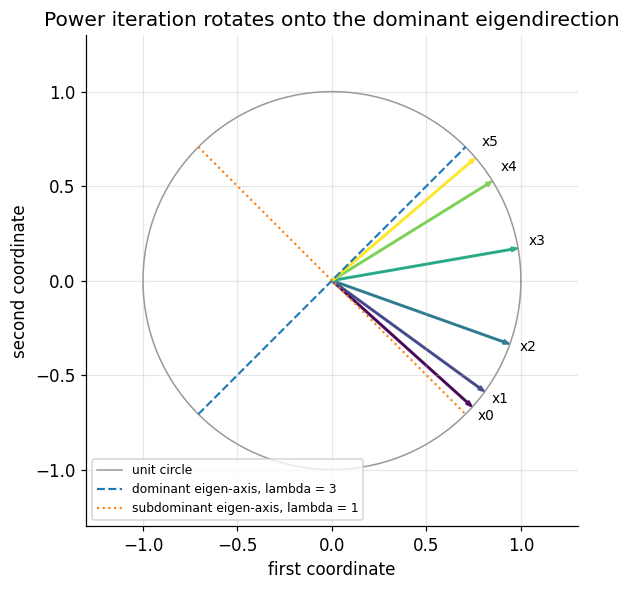

k   sin(angle to dominant axis)   ratio to previous
0   9.986178e-01              
1   9.877630e-01              0.989130
2   9.037378e-01              0.914934
3   5.754934e-01              0.636792
4   2.283693e-01              0.396824
5   7.795138e-02              0.341339
6   2.605425e-02              0.334237
7   8.687372e-03              0.333434
8   2.895888e-03              0.333345
9   9.652996e-04              0.333335

predicted ratio lambda_2 / lambda_1 = 0.333333


In [2]:
A2 = np.array([[2.0, 1.0], [1.0, 2.0]])
q1 = np.array([1.0, 1.0]) / np.sqrt(2.0)
q2 = np.array([1.0, -1.0]) / np.sqrt(2.0)

x = np.array([1.0, -0.9])
x /= np.linalg.norm(x)
iterates = [x.copy()]
for _ in range(9):
    x = A2 @ x
    x /= np.linalg.norm(x)
    iterates.append(x.copy())
iterates = np.array(iterates)
shown = iterates[:6]

t = np.linspace(0.0, 2.0 * np.pi, 400)
fig, ax = plt.subplots(figsize=(5.8, 5.8))
ax.plot(np.cos(t), np.sin(t), lw=1.0, color="0.6", label="unit circle")
ax.plot([-q1[0], q1[0]], [-q1[1], q1[1]], lw=1.4, ls="--",
        label="dominant eigen-axis, lambda = 3")
ax.plot([-q2[0], q2[0]], [-q2[1], q2[1]], lw=1.4, ls=":",
        label="subdominant eigen-axis, lambda = 1")
for k, v in enumerate(shown):
    ax.arrow(0.0, 0.0, v[0], v[1], width=0.008, length_includes_head=True,
             color=plt.cm.viridis(k / (len(shown) - 1)), alpha=0.9)
    ax.annotate(f"x{k}", v * 1.10, ha="center", fontsize=9)
ax.set_aspect("equal")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_xlabel("first coordinate")
ax.set_ylabel("second coordinate")
ax.set_title("Power iteration rotates onto the dominant eigendirection")
ax.legend(loc="lower left", fontsize=8)
plt.show()

sin_theta = [np.linalg.norm(v - (q1 @ v) * q1) for v in iterates]
print("k   sin(angle to dominant axis)   ratio to previous")
for k, s in enumerate(sin_theta):
    tail = "" if k == 0 else f"{s / sin_theta[k - 1]:.6f}"
    print(f"{k}   {s:.6e}              {tail}")
print(f"\npredicted ratio lambda_2 / lambda_1 = {1 / 3:.6f}")

The arrows swing onto the dashed axis. The printed ratios start near $1$ — because $x_0$ was
planted almost on the *wrong* axis — and then settle: $0.397$, $0.341$, $0.334$, $0.3334$,
$0.33334$, converging to $1/3 = \lambda_2/\lambda_1$.

Nothing about the picture depends on the dimension: in $\mathbb{R}^{n}$ the same contraction
happens in the plane spanned by $q_1$ and whatever else $x_k$ contains.

The rate is the *only* thing an algorithm designer can change, and the next sections change it by
inverting, by shifting, and by projecting.

## 3. Definitions

Throughout, $A \in \mathbb{R}^{n \times n}$ unless stated otherwise, $A^{\ast}$ is the conjugate
transpose, vectors are columns, and eigenvalues are listed in **descending modulus**
$\lvert \lambda_1 \rvert \ge \lvert \lambda_2 \rvert \ge \dots \ge \lvert \lambda_n \rvert$;
for a symmetric matrix this coincides with the descending order
$\lambda_1 \ge \dots \ge \lambda_n$ fixed in
[the notation register](../../docs/notation.md). Norms are written $\lVert x \rVert$.

> [!NOTE]
> **Declared symbol collision.** In this module $T$ always denotes a triangular or tridiagonal
> matrix — the Schur factor, the tridiagonal form of a symmetric matrix, or the Lanczos matrix
> $T_m$. It is never a Chebyshev polynomial, which is the repository-wide meaning of $T_k$ fixed
> in [the notation register](../../docs/notation.md). Chebyshev polynomials do not appear in this
> module; they belong to
> [Module 08](../08_numerical_linear_algebra_iterative_solvers/first_principles.ipynb).
> Likewise $d$ is the PageRank damping factor and $\alpha_j$, $\beta_j$ are Lanczos coefficients.

### Definition 3.1 — Rayleigh quotient and Ritz pair

For symmetric $A$ and $x \neq 0$ the **Rayleigh quotient** is

$$
R_A(x) = \frac{x^{\top} A x}{x^{\top} x}.
$$

Given a subspace $\mathcal{S}$ with orthonormal basis $Q \in \mathbb{R}^{n \times m}$, a
**Ritz pair** $(\theta, y)$ of $A$ with respect to $\mathcal{S}$ is $y = Qs$, $\theta$ a scalar,
with

$$
Q^{\top} A Q \, s = \theta s .
$$

The scalar $\theta$ is a **Ritz value** and $y$ a **Ritz vector**. They are the best eigenpair
estimates obtainable from $\mathcal{S}$ in the sense that $Ay - \theta y \perp \mathcal{S}$.

### Definition 3.2 — Power, inverse and Rayleigh quotient iteration

Given a unit vector $x_0$:

- **power iteration**: $x_{k+1} = A x_k / \lVert A x_k \rVert$;
- **shifted inverse iteration** with fixed $\mu \notin \operatorname{spec}(A)$: solve
  $(A - \mu I) y_{k+1} = x_k$, then $x_{k+1} = y_{k+1} / \lVert y_{k+1} \rVert$;
- **Rayleigh quotient iteration (RQI)**: the same, but with the shift refreshed every step,
  $\mu_k = R_A(x_k)$.

The three differ only in which spectrum the competition of Section 2 is run on:
$\lbrace \lambda_i \rbrace$, $\lbrace (\lambda_i - \mu)^{-1} \rbrace$, and a moving target.

### Definition 3.3 — Hessenberg and tridiagonal form

$H \in \mathbb{R}^{n \times n}$ is **upper Hessenberg** when $h_{ij} = 0$ for $i \gt j + 1$, and
**unreduced** when in addition $h_{i+1,i} \neq 0$ for every $i$.

A symmetric upper Hessenberg matrix is **tridiagonal**: $t_{ij} = 0$ whenever
$\lvert i - j \rvert \gt 1$.

Unreducedness matters because a zero subdiagonal entry splits the eigenproblem into two smaller
ones — which is exactly what **deflation** exploits.

### Definition 3.4 — The QR algorithm

Set $A_0 = A$. For $k = 0, 1, 2, \dots$ factor and reverse:

$$
A_k - \mu_k I = Q_k R_k, \qquad A_{k+1} = R_k Q_k + \mu_k I .
$$

The **unshifted** algorithm is the case $\mu_k = 0$. Each $Q_k$ is orthogonal and each $R_k$ is
upper triangular; to make the factorization unique we always take $R_k$ with a **positive
diagonal**, which is possible whenever $A_k - \mu_k I$ is nonsingular.

### Definition 3.5 — Wilkinson shift

Let the trailing $2 \times 2$ block of a symmetric tridiagonal $T$ be

$$
\begin{pmatrix} t_{n-1,n-1} & t_{n,n-1} \\ t_{n,n-1} & t_{nn} \end{pmatrix},
\qquad
d = \frac{t_{n-1,n-1} - t_{nn}}{2} .
$$

With the convention $\operatorname{sgn}(0) = 1$, the **Wilkinson shift** is

$$
\mu = t_{nn} - \frac{t_{n,n-1}^{2}}{d + \operatorname{sgn}(d)\sqrt{d^{2} + t_{n,n-1}^{2}}} .
$$

Proposition 4.10 shows this is well defined, equals the eigenvalue of the trailing block nearer
to $t_{nn}$, and is written in the form that avoids cancellation.

### Definition 3.6 — Krylov subspace

For $b \neq 0$,

$$
\mathcal{K}_m(A, b) = \operatorname{span}\lbrace b, Ab, A^{2}b, \dots, A^{m-1}b \rbrace .
$$

Its dimension is $\min(m, d_b)$ where $d_b$ is the degree of the minimal polynomial of $b$ with
respect to $A$. A Krylov method touches $A$ only through the map $v \mapsto Av$, which is why it
survives at $n = 10^{6}$ when $A$ is sparse or is available only as a routine.

### Definition 3.7 — Order of convergence

A sequence $e_k \to 0$ converges with **order** $p \ge 1$ and rate $C$ when

$$
e_{k+1} \le C e_k^{\,p}
$$

for all large $k$. Order $1$ with $C \lt 1$ is **linear**, $p = 2$ **quadratic**, $p = 3$
**cubic**. Linear convergence adds a fixed number of correct digits per step; cubic convergence
triples the number of correct digits per step.

## 4. Main Results

Theorems 4.1 and 4.2 give the rates of the two vector iterations. Theorem 4.3 identifies what the
QR algorithm is really doing, and Theorem 4.4 — the result this module exists for — turns that
identification into a convergence theorem with the hypotheses it actually needs.

Theorems 4.5 and 4.6 are what makes the QR algorithm affordable. Theorems 4.7 and 4.8 are the
Krylov half of the subject, and Theorem 4.9 collects the two results quoted rather than proved.
Propositions 4.10 to 4.12 record the shift, the Jacobi sweep and the divide-and-conquer secular
equation.

### Theorem 4.1 — Shifted inverse iteration

Let $A \in \mathbb{R}^{n \times n}$ be symmetric with orthonormal eigenvectors
$q_1, \dots, q_n$ and eigenvalues $\lambda_1, \dots, \lambda_n$. Fix $\mu \notin \operatorname{spec}(A)$
and let $j$ be an index with

$$
\lvert \lambda_j - \mu \rvert \lt \gamma_\mu := \min_{i \neq j} \lvert \lambda_i - \mu \rvert .
$$

If $q_j^{\top} x_0 \neq 0$, then the shifted inverse iterates of Definition 3.2 satisfy

$$
\tan \theta(x_k, q_j) \;\le\; r^{\,k} \tan \theta(x_0, q_j),
\qquad
r = \frac{\lvert \lambda_j - \mu \rvert}{\gamma_\mu} \lt 1 ,
$$

where $\theta(u,v) = \arccos \lvert u^{\top} v \rvert$.

**Hypotheses.** $\mu \notin \operatorname{spec}(A)$ makes $A - \mu I$ invertible, so the step is
defined. The strict inequality $\lvert \lambda_j - \mu \rvert \lt \gamma_\mu$ is what makes
$r \lt 1$; with a tie the iteration rotates inside a two-dimensional eigenspace and need not
converge to a single direction. And $q_j^{\top} x_0 \neq 0$ excludes starting orthogonal to the
answer.

**Interpretation.** The shift is a free parameter that buys accuracy: moving $\mu$ towards
$\lambda_j$ drives $r$ to zero. This is why an *approximate* eigenvalue is worth so much — it is
the input that makes the next iteration fast.

Proved as Proof 5.1.

### Theorem 4.2 — Rayleigh quotient iteration converges cubically

Let $A \in \mathbb{R}^{n \times n}$ be symmetric with a **simple** eigenvalue $\lambda_j$, unit
eigenvector $q_j$, gap $\gamma = \min_{i \neq j} \lvert \lambda_i - \lambda_j \rvert \gt 0$ and
spread $\Delta = \lambda_1 - \lambda_n$. Write $\theta_k = \theta(x_k, q_j)$ for the RQI iterates
of Definition 3.2.

If the starting angle satisfies

$$
\Delta \sin^{2}\theta_0 \le \frac{\gamma}{2}
\qquad\text{and}\qquad
\frac{2\Delta}{\gamma}\tan^{2}\theta_0 \lt 1 ,
$$

then every iterate is defined, $\theta_k \to 0$, and

$$
\tan \theta_{k+1} \;\le\; \frac{2\Delta}{\gamma} \, \tan^{3}\theta_k .
$$

**Hypotheses.** Symmetry gives the orthonormal eigenbasis in which the Rayleigh quotient is a
weighted average of eigenvalues, which is what makes the shift error *quadratic* in the angle;
for a non-symmetric matrix the one-sided Rayleigh quotient is only linearly accurate and RQI
degrades to quadratic. Simplicity of $\lambda_j$ gives $\gamma \gt 0$; without a gap the
inverse $(A - \mu_k I)^{-1}$ has no dominant direction to select. The two smallness conditions
are what keep the recursion inside its basin.

**Interpretation.** Each step triples the number of correct digits. Example 6.2 exhibits a
$2 \times 2$ case where the recursion is the exact identity
$\tan\theta_{k+1} = -\tan^{3}\theta_k$.

Proved as Proof 5.2.

### Theorem 4.3 — The QR algorithm is simultaneous subspace iteration

Let $A_0 = A$ and $A_{k+1} = R_k Q_k$ with $A_k = Q_k R_k$ the unshifted QR step of
Definition 3.4. Put

$$
\underline{Q}_k = Q_0 Q_1 \cdots Q_{k-1},
\qquad
\underline{R}_k = R_{k-1} \cdots R_1 R_0 .
$$

Then for every $k \ge 1$

$$
A_k = \underline{Q}_k^{\top} A \, \underline{Q}_k
\qquad\text{and}\qquad
A^{k} = \underline{Q}_k \underline{R}_k .
$$

In particular the first $j$ columns of $\underline{Q}_k$ are an orthonormal basis of
$\operatorname{Col}(A^{k} E_j)$, where $E_j$ holds the first $j$ columns of $I$ — the result of
$k$ steps of subspace iteration started from the coordinate flag.

**Hypotheses.** Only that each QR factorization exists, which is automatic; the identification of
column spaces additionally needs $A$ nonsingular so that $\underline{R}_k$ is invertible.

**Interpretation.** The QR algorithm never forms $A^{k}$, whose entries overflow, yet it produces
exactly the orthonormal basis that $A^{k}$ would have produced. That is the whole trick.

Proved as Proof 5.3.

### Theorem 4.4 — Convergence of the unshifted QR algorithm

Let $A \in \mathbb{R}^{n \times n}$ be diagonalizable, $A = X \Lambda X^{-1}$, with

$$
\lvert \lambda_1 \rvert \gt \lvert \lambda_2 \rvert \gt \dots \gt \lvert \lambda_n \rvert \gt 0,
\qquad \Lambda = \operatorname{diag}(\lambda_1, \dots, \lambda_n),
$$

and suppose $Y := X^{-1}$ admits an **LU factorization without pivoting**, $Y = LU$ with $L$ unit
lower triangular and $U$ upper triangular; equivalently every leading principal minor of $Y$ is
nonzero.

Then, for every $j \in \lbrace 1, \dots, n-1 \rbrace$, the block of the unshifted QR iterate
$A_k$ lying strictly below the $j$-th diagonal entry obeys

$$
\left\lVert (A_k)_{j+1:n,\; 1:j} \right\rVert_2
\;=\; O\!\left( \left\lvert \frac{\lambda_{j+1}}{\lambda_j} \right\rvert^{k} \right),
$$

so in particular every subdiagonal entry decays at the rate of its own eigenvalue ratio,

$$
\lvert (A_k)_{j+1,j} \rvert = O\!\left( \left\lvert \frac{\lambda_{j+1}}{\lambda_j} \right\rvert^{k} \right),
$$

every entry below the diagonal tends to zero, and the diagonal converges to the spectrum in
decreasing modulus,

$$
(A_k)_{jj} \longrightarrow \lambda_j \qquad (j = 1, \dots, n) .
$$

**Hypotheses, one sentence each.**

- *Diagonalizability* supplies the factorization $A^{k} = X\Lambda^{k}Y$ that the whole proof
  runs on.
- *Strictly decreasing moduli* make every ratio $\lvert \lambda_{i+1}/\lambda_i \rvert$ less than
  one; with $\lvert \lambda_1 \rvert = \lvert \lambda_2 \rvert$ the algorithm can stall forever,
  as $\left(\begin{smallmatrix}0 & 1\\ 1 & 0\end{smallmatrix}\right)$ does in Section 7.3.
- *No zero eigenvalue* makes $A$ invertible, which is what Theorem 4.3 needs to identify
  $\operatorname{Col}(A^{k}E_j)$ with a column space of $\underline{Q}_k$, and makes
  $\Lambda_1^{-k}$ defined.
- *Pivot-free LU of $X^{-1}$* is what makes the leading $j \times j$ block of $L$ invertible, and
  hence makes $\operatorname{Col}(A^{k}E_j)$ converge to the dominant $j$-dimensional invariant
  subspace; dropping it does **not** merely slow the algorithm, it changes the limit, as
  $\left(\begin{smallmatrix}1 & 1\\ 0 & 2\end{smallmatrix}\right)$ shows in Section 7.3, where the
  diagonal converges to $(1, 2)$ — the eigenvalues in *increasing* modulus.

**What is not claimed.** The matrices $A_k$ themselves need not converge: the strictly upper
triangular entries may keep changing sign. Only the moduli below the diagonal and the diagonal
entries converge.

Some texts quote the sharper entrywise form
$\lvert (A_k)_{ij} \rvert = O(\lvert \lambda_i/\lambda_j \rvert^{k})$ for all $i \gt j$. The
block statement above gives it for $i = j+1$, which is the case every implementation uses as its
deflation criterion, and gives
$\lvert (A_k)_{ij} \rvert = O(\lvert \lambda_{j+1}/\lambda_j \rvert^{k})$ in general. The
sharper form for a far-off-diagonal entry needs a further argument and is not claimed here.

Proved as Proof 5.4. This is the theorem the module is named after, and it is proved here in
full.

### Theorem 4.5 — Hessenberg form is invariant, and cheap

Let $H \in \mathbb{R}^{n \times n}$ be upper Hessenberg and let $H = QR$ be a QR factorization
produced by the $n-1$ Givens rotations $G_1, \dots, G_{n-1}$, where $G_i$ acts on rows $i, i+1$.
Then $Q = G_1^{\top} \cdots G_{n-1}^{\top}$ is upper Hessenberg, and

$$
H_{+} = RQ
$$

is upper Hessenberg. The factorization and the product together cost $O(n^{2})$ flops, and
$O(n)$ when $H$ is symmetric tridiagonal.

**Hypotheses.** None beyond squareness; the Givens construction never requires $H$ to be
invertible. If $H$ is additionally symmetric, so is $H_{+} = Q^{\top}HQ$, hence tridiagonal.

**Interpretation.** Reduce once to Hessenberg form at $\tfrac{10}{3}n^{3}$ flops
($\tfrac{4}{3}n^{3}$ in the symmetric case) and every subsequent QR step costs $O(n^{2})$ instead
of $O(n^{3})$. This single observation is what took the QR algorithm from unusable to standard.

Proved as Proof 5.5.

### Theorem 4.6 — Implicit Q theorem

Let $A \in \mathbb{R}^{n \times n}$ and let $Q, V$ be orthogonal with

$$
Q^{\top} A Q = H, \qquad V^{\top} A V = G,
$$

both **unreduced** upper Hessenberg. If $Q e_1 = V e_1$, then there is a diagonal
$D = \operatorname{diag}(\pm 1, \dots, \pm 1)$ with

$$
V = QD \qquad\text{and}\qquad G = D H D .
$$

**Hypotheses.** Unreducedness is essential: it is the nonvanishing of $g_{j+1,j}$ that lets the
induction solve for the next column. With a zero subdiagonal entry the problem splits and the two
blocks may be reduced independently, destroying uniqueness.

**Interpretation.** A Hessenberg reduction is pinned down by its first column alone. That is the
licence for **bulge chasing**: apply one rotation matching the first column of
$(A - \mu I)e_1$, chase the resulting bulge back down the subdiagonal, and the result is the
shifted QR step — without ever forming $A - \mu I$ or its QR factorization.

Proved as Proof 5.6.

### Theorem 4.7 — Arnoldi and Lanczos

Let $b \neq 0$ and suppose $\dim \mathcal{K}_{m+1}(A, b) = m + 1$. The Arnoldi process produces
orthonormal $q_1, \dots, q_{m+1}$ with
$\operatorname{span}\lbrace q_1, \dots, q_j \rbrace = \mathcal{K}_j(A, b)$ and

$$
A Q_m = Q_m H_m + h_{m+1,m}\, q_{m+1} e_m^{\top},
\qquad H_m = Q_m^{\top} A Q_m \ \text{upper Hessenberg} ,
$$

where $Q_m = [\, q_1 \ \cdots \ q_m \,]$.

If in addition $A = A^{\top}$, then $H_m = T_m$ is symmetric tridiagonal and the Arnoldi
recurrence collapses to the **three-term Lanczos recurrence**

$$
\beta_j q_{j+1} = A q_j - \alpha_j q_j - \beta_{j-1} q_{j-1},
\qquad \alpha_j = q_j^{\top} A q_j, \quad \beta_j = \lVert \cdot \rVert_2 \ \text{of the right side}.
$$

**Hypotheses.** The dimension condition is exactly "no breakdown": if
$\dim \mathcal{K}_{m+1}(A,b) = m$ then $h_{m+1,m} = 0$, $\mathcal{K}_m$ is an invariant subspace,
and the Ritz values are **exact** eigenvalues — a lucky breakdown, illustrated in Example 6.5.
Symmetry is what forces the Hessenberg matrix to be tridiagonal; without it every new vector must
be orthogonalized against all previous ones.

Proved as Proof 5.7.

### Theorem 4.8 — The Ritz residual is known exactly

In the setting of Theorem 4.7 with $A$ symmetric, let $T_m s_i = \theta_i s_i$ with
$\lVert s_i \rVert_2 = 1$ and let $y_i = Q_m s_i$ be the corresponding Ritz vector. Then

$$
A y_i - \theta_i y_i = \beta_m \, (e_m^{\top} s_i) \, q_{m+1},
\qquad\text{hence}\qquad
\lVert A y_i - \theta_i y_i \rVert_2 = \beta_m \lvert s_{mi} \rvert .
$$

**Hypotheses.** Exact arithmetic and $\lVert q_{m+1} \rVert_2 = 1$. Nothing else.

**Interpretation.** The residual of a Ritz pair costs nothing: it is the last subdiagonal entry
times the last component of the small eigenvector. A Lanczos code therefore knows, at every step
and for every Ritz value, how converged it is — without touching $A$ again. Combined with
Theorem 4.9 it also predicts when orthogonality is about to be lost.

Proved as Proof 5.8.

### Theorem 4.9 (cited, not proved here) — Wilkinson's cubic rate and Paige's bound

**Cubic convergence of the shifted symmetric QR algorithm.** For a symmetric unreduced
tridiagonal $T$ and the Wilkinson shift of Definition 3.5, the trailing subdiagonal entry
satisfies $\lvert t^{(k+1)}_{n,n-1} \rvert = O\!\left( \lvert t^{(k)}_{n,n-1} \rvert^{3} \right)$
whenever the iteration converges, and convergence always occurs. Sources: Wilkinson,
*The Algebraic Eigenvalue Problem*, Ch. 8 section 39 (global convergence); Golub and Van Loan,
*Matrix Computations*, 4th ed., section 8.3.4, "the Wilkinson shift strategy is cubically
convergent"; Parlett, *The Symmetric Eigenvalue Problem*, Ch. 8 section 8.10.

**Paige's loss-of-orthogonality bound.** Run the Lanczos process of Theorem 4.7 in floating-point
arithmetic with unit roundoff $u$, and let $(\theta_i, y_i)$ be a Ritz pair at step $m$ with
computed residual norm $\beta_m \lvert s_{mi} \rvert$. Then

$$
\lvert q_{m+1}^{\top} y_i \rvert
\;=\; O\!\left( \frac{u \, \lVert A \rVert_2}{\beta_m \lvert s_{mi} \rvert} \right)
$$

with a constant depending polynomially on $m$ and $n$. Source: Paige, "Error analysis of the
Lanczos algorithm for tridiagonalizing a symmetric matrix", *IMA Journal of Applied Mathematics*
**18**(3), 1976, 341-349, Theorem 4; see also Parlett, *The Symmetric Eigenvalue Problem*,
Ch. 13 section 13.4.

Note that $q_{m+1}^{\top}y_i$ is a **scalar**, so the absolute value, not a norm, is the correct
bracket, and the relation is an order-of-magnitude estimate rather than an inequality with an
explicit constant.

**The strongest special case is proved in full.** The denominator of Paige's bound is exactly the
quantity of Theorem 4.8, proved here as an identity in Proof 5.8. Section 7.5 measures both sides.

**Interpretation.** Orthogonality is not lost gradually through accumulated rounding: it is lost
precisely and abruptly in the direction of a Ritz vector at the moment that Ritz pair converges.
Convergence and loss of orthogonality are the same event.

### Proposition 4.10 — The Wilkinson shift is well defined and closest

Let $B = \left(\begin{smallmatrix} a & b \\ b & c \end{smallmatrix}\right)$ be real symmetric with
$b \neq 0$, put $d = (a-c)/2$ and use $\operatorname{sgn}(0) = 1$. Then the denominator
$d + \operatorname{sgn}(d)\sqrt{d^{2}+b^{2}}$ is nonzero — equal to $\lvert b \rvert$ when $d = 0$ —
and the Wilkinson shift of Definition 3.5 satisfies

$$
\mu = c + d - \operatorname{sgn}(d)\sqrt{d^{2}+b^{2}} ,
$$

which is the eigenvalue of $B$ nearer to $c$.

**Hypotheses.** $b \neq 0$; if $b = 0$ the block is already diagonal and the eigenvalue is read
off. The convention $\operatorname{sgn}(0) = 1$ is a *choice*: when $d = 0$ the two eigenvalues
$c \pm \lvert b \rvert$ are equidistant from $c$ and something must break the tie.

**Interpretation.** The two displayed forms are algebraically identical and numerically are not.
When $\lvert b \rvert \ll \lvert d \rvert$ the subtraction
$d - \operatorname{sgn}(d)\sqrt{d^{2}+b^{2}}$ cancels catastrophically, while the quotient form of
Definition 3.5 adds two same-signed quantities and then divides. Definition 3.5 is the one to
implement.

Proved as Proof 5.9.

### Proposition 4.11 — A Jacobi rotation strictly reduces the off-diagonal norm

For symmetric $A$ write $\operatorname{off}(A)^{2} = \lVert A \rVert_F^{2} - \sum_i a_{ii}^{2}$.
Let $J$ be the Givens rotation in the plane $(p,q)$ chosen so that $(J^{\top}AJ)_{pq} = 0$, which
requires $\cot 2\vartheta = (a_{qq} - a_{pp})/(2a_{pq})$. Then

$$
\operatorname{off}(J^{\top} A J)^{2} = \operatorname{off}(A)^{2} - 2 a_{pq}^{2} .
$$

**Hypotheses.** $A$ symmetric, so that $J^{\top}AJ$ is symmetric and the Frobenius norm is
preserved by the orthogonal similarity.

**Interpretation.** Annihilating the largest off-diagonal entry removes at least
$2\operatorname{off}(A)^{2}/(n^{2}-n)$ from the off-diagonal mass, so the classical Jacobi method
converges. It is the slowest of the dense symmetric solvers and the most accurate for graded
matrices, which is why it survives. It is implemented in
[Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb), section 7.4.

Proved as Proof 5.10.

### Proposition 4.12 — The divide-and-conquer secular equation

Let $T \in \mathbb{R}^{n \times n}$ be symmetric tridiagonal, split at index $k$ with
$\beta = t_{k+1,k}$ and $u = e_k + e_{k+1}$, so that

$$
T = \begin{pmatrix} T_1 & 0 \\ 0 & T_2 \end{pmatrix} + \beta u u^{\top},
\qquad
T_1 = T(1{:}k,\, 1{:}k) - \beta e_k e_k^{\top},
\quad
T_2 = T(k{+}1{:}n,\, k{+}1{:}n) - \beta e_1 e_1^{\top} .
$$

With $T_1 = Q_1 D_1 Q_1^{\top}$, $T_2 = Q_2 D_2 Q_2^{\top}$, $D = \operatorname{diag}(D_1, D_2)$
and $z = \operatorname{diag}(Q_1, Q_2)^{\top} u$, every eigenvalue $\lambda$ of $T$ that is not
already a diagonal entry of $D$ is a root of the **secular equation**

$$
f(\lambda) = 1 + \beta \sum_{i=1}^{n} \frac{z_i^{2}}{d_i - \lambda} = 0 .
$$

**Hypotheses.** $\beta \neq 0$, else the problem is already split. Eigenvalues of $T$ that
coincide with some $d_i$ correspond to $z_i = 0$ and are handled by **deflation**, not by the
equation.

**Interpretation.** Solving one $n \times n$ symmetric tridiagonal problem is reduced to two of
half the size plus a scalar root-find with $n$ poles. The worst case is $O(n^{3})$; deflation is
so common in practice that the observed cost is about $O(n^{2.3})$, and $O(n^{2})$ only when
deflation is extreme. Any claim that divide-and-conquer is $O(n^{2})$ in general is wrong.

Proved as Proof 5.11.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, shifted inverse iteration)

The matrix $(A - \mu I)^{-1}$ is symmetric with the **same** eigenvectors as $A$ and eigenvalues
$(\lambda_i - \mu)^{-1}$, because $Aq_i = \lambda_i q_i$ gives
$(A - \mu I)q_i = (\lambda_i - \mu) q_i$ and $\lambda_i - \mu \neq 0$.

Normalization does not change a direction, so $x_k$ spans the same line as
$(A - \mu I)^{-k} x_0$. Expand $x_0 = \sum_i c_i q_i$ with $c_j \neq 0$:

$$
(A - \mu I)^{-k} x_0 = \sum_{i=1}^{n} \frac{c_i}{(\lambda_i - \mu)^{k}} \, q_i .
$$

Split the sum into its $q_j$ component and the rest. Because the $q_i$ are orthonormal,

$$
\tan \theta(x_k, q_j)
= \frac{\Bigl( \sum_{i \neq j} c_i^{2} \lvert \lambda_i - \mu \rvert^{-2k} \Bigr)^{1/2}}
       {\lvert c_j \rvert \, \lvert \lambda_j - \mu \rvert^{-k}} .
$$

For every $i \neq j$ we have $\lvert \lambda_i - \mu \rvert \ge \gamma_\mu$, hence
$\lvert \lambda_i - \mu \rvert^{-2k} \le \gamma_\mu^{-2k}$. Pulling that bound out of the sum,

$$
\tan \theta(x_k, q_j)
\;\le\; \left( \frac{\lvert \lambda_j - \mu \rvert}{\gamma_\mu} \right)^{k}
\frac{\bigl( \sum_{i \neq j} c_i^{2} \bigr)^{1/2}}{\lvert c_j \rvert}
= r^{\,k} \tan \theta(x_0, q_j) . \qquad \blacksquare
$$

**Interpretation.** Power iteration is the same statement with the roles of large and small
reversed; it is proved as Theorem 4.7 of
[Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb). What is new
here is that $\mu$ is under the user's control, so $r$ can be made arbitrarily small.

### Proof 5.2 (of Theorem 4.2, cubic convergence of RQI)

Write the unit iterate in the orthonormal eigenbasis as

$$
x_k = \cos\theta_k \, q_j + \sin\theta_k \, w_k, \qquad w_k \perp q_j, \ \lVert w_k \rVert = 1 .
$$

If $\sin\theta_k = 0$ then $x_k = \pm q_j$, the iteration has already converged, and there is
nothing to prove. Assume $\sin\theta_k \gt 0$.

**Step 1 — the shift error is quadratic in the angle.**

Since $q_j^{\top} A w_k = \lambda_j q_j^{\top} w_k = 0$, the cross terms vanish and

$$
\mu_k = R_A(x_k) = \cos^{2}\theta_k \, \lambda_j + \sin^{2}\theta_k \, R_A(w_k) .
$$

Subtracting $\lambda_j = (\cos^{2}\theta_k + \sin^{2}\theta_k)\lambda_j$,

$$
\mu_k - \lambda_j = \sin^{2}\theta_k \, \bigl( R_A(w_k) - \lambda_j \bigr) .
$$

A Rayleigh quotient is a weighted average of eigenvalues, so
$R_A(w_k) \in [\lambda_n, \lambda_1]$ and therefore

$$
\lvert \mu_k - \lambda_j \rvert \;\le\; \Delta \sin^{2}\theta_k .
$$

**Step 2 — the step is well defined.**

Assume inductively $\Delta \sin^{2}\theta_k \le \gamma/2$, which holds at $k = 0$ by hypothesis.
Then $\lvert \mu_k - \lambda_j \rvert \le \gamma/2$, so for every $i \neq j$

$$
\lvert \lambda_i - \mu_k \rvert \;\ge\; \lvert \lambda_i - \lambda_j \rvert - \lvert \lambda_j - \mu_k \rvert
\;\ge\; \gamma - \frac{\gamma}{2} = \frac{\gamma}{2} \;\gt\; 0 ,
$$

If $\mu_k = \lambda_j$ the matrix $A - \mu_kI$ is singular with null space
$\operatorname{span}(q_j)$; the shift is then exact, one takes $x_{k+1} = q_j$, and
$\theta_{k+1} = 0$, so the claimed inequality holds trivially. Assume therefore
$\mu_k \neq \lambda_j$, which together with the display above makes $A - \mu_kI$ invertible.

**Step 3 — one inverse-iteration step.**

Apply $(A - \mu_k I)^{-1}$ and split along $q_j$:

$$
y_{k+1} = (A - \mu_k I)^{-1} x_k
= \frac{\cos\theta_k}{\lambda_j - \mu_k} \, q_j \;+\; \sin\theta_k \, (A - \mu_k I)^{-1} w_k .
$$

The second term stays orthogonal to $q_j$, because $w_k$ lies in the span of the other
eigenvectors, which is invariant under $(A - \mu_k I)^{-1}$. By Step 2 its norm obeys
$\lVert (A - \mu_k I)^{-1} w_k \rVert \le 2/\gamma$.

The tangent of the new angle is the ratio of the two norms:

$$
\tan\theta_{k+1}
\;\le\; \frac{\sin\theta_k \cdot 2/\gamma}{\lvert \cos\theta_k \rvert / \lvert \lambda_j - \mu_k \rvert}
\;=\; \tan\theta_k \cdot \frac{2 \lvert \lambda_j - \mu_k \rvert}{\gamma} .
$$

**Step 4 — insert the quadratic shift error.**

By Step 1 and $\sin\theta_k \le \tan\theta_k$,

$$
\tan\theta_{k+1} \;\le\; \tan\theta_k \cdot \frac{2\Delta \sin^{2}\theta_k}{\gamma}
\;\le\; \frac{2\Delta}{\gamma} \, \tan^{3}\theta_k ,
$$

which is the claimed inequality.

**Step 5 — the induction closes.**

Put $c = 2\Delta/\gamma$ and $s_k = c^{1/2}\tan\theta_k$. Step 4 reads $s_{k+1} \le s_k^{3}$, and
$s_0 \lt 1$ by hypothesis, so $s_k \le s_0^{3^{k}} \to 0$. In particular $\tan\theta_k$ is
non-increasing, hence so is $\sin\theta_k$, so the inductive assumption
$\Delta\sin^{2}\theta_k \le \gamma/2$ of Step 2 survives every step. $\blacksquare$

**Interpretation.** Two ingredients multiply: inverse iteration contracts the angle by
$\lvert \lambda_j - \mu_k \rvert / \gamma$, and the Rayleigh quotient makes that factor itself
quadratic in the angle. One linear step times one quadratic shift gives order $3$.

### Proof 5.3 (of Theorem 4.3, QR as subspace iteration)

**Similarity.** From $A_k = Q_k R_k$ and $Q_k^{\top}Q_k = I$ we get $R_k = Q_k^{\top}A_k$, hence

$$
A_{k+1} = R_k Q_k = Q_k^{\top} A_k Q_k .
$$

Chaining this from $A_0 = A$ gives $A_k = \underline{Q}_k^{\top} A \, \underline{Q}_k$.

**The power identity.** Induct on $k$. For $k = 1$, $A = Q_0R_0 = \underline{Q}_1\underline{R}_1$.

Assume $A^{k} = \underline{Q}_k \underline{R}_k$. Then

$$
\underline{Q}_{k+1}\underline{R}_{k+1}
= \underline{Q}_k Q_k \, R_k \underline{R}_k
= \underline{Q}_k A_k \underline{R}_k ,
$$

because $Q_kR_k = A_k$. Substituting $A_k = \underline{Q}_k^{\top}A\underline{Q}_k$ and using
$\underline{Q}_k\underline{Q}_k^{\top} = I$,

$$
\underline{Q}_{k+1}\underline{R}_{k+1}
= \underline{Q}_k \underline{Q}_k^{\top} A \underline{Q}_k \underline{R}_k
= A \, \underline{Q}_k\underline{R}_k
= A \cdot A^{k} = A^{k+1} .
$$

**Column spaces.** Let $E_j$ hold the first $j$ columns of $I$. If $A$ is nonsingular so is
$\underline{R}_k$, and because $\underline{R}_k$ is upper triangular,
$\underline{R}_k E_j = E_j \, (\underline{R}_k)_{1:j,1:j}$ with the leading block invertible.
Hence

$$
\operatorname{Col}(A^{k}E_j) = \operatorname{Col}(\underline{Q}_k \underline{R}_k E_j)
= \operatorname{Col}(\underline{Q}_k E_j),
$$

the span of the first $j$ columns of $\underline{Q}_k$. $\blacksquare$

**Interpretation.** One QR step per iteration silently carries out orthonormal subspace iteration
on all $n$ nested coordinate subspaces simultaneously, and does it without ever forming $A^{k}$.

### Proof 5.4 (of Theorem 4.4, convergence of the unshifted QR algorithm)

Fix $j$ and abbreviate $\theta_j = \lvert \lambda_{j+1}/\lambda_j \rvert \lt 1$. Partition

$$
\Lambda = \begin{pmatrix} \Lambda_1 & 0 \\ 0 & \Lambda_2 \end{pmatrix},
\qquad
L E_j = \begin{pmatrix} L_{11} \\ L_{21} \end{pmatrix},
$$

with $\Lambda_1, L_{11} \in \mathbb{R}^{j \times j}$.

**Step 1 — the $j$-th subspace is generated by $\Lambda^{k} L E_j$.**

By hypothesis $A^{k} = X\Lambda^{k}Y = X\Lambda^{k}LU$. Since $U$ is upper triangular,
$U E_j = E_j U_{11}$ with $U_{11}$ the leading $j \times j$ block, invertible because $U$ is.
Therefore

$$
\operatorname{Col}(A^{k}E_j) = \operatorname{Col}\bigl( X \Lambda^{k} L E_j \bigr) .
$$

**Step 2 — where the LU hypothesis is used.**

$L$ is unit lower triangular, so $L_{11}$ is unit lower triangular and therefore **invertible**.
This is the only place the pivot-free LU hypothesis enters, and it is indispensable: without it
$\Lambda^{k}LE_j$ can fail to have full column rank in the limit and the subspace converges
somewhere else.

Right-multiplying by the invertible matrix $(\Lambda_1^{k} L_{11})^{-1}$ does not change a column
space, so

$$
\operatorname{Col}(A^{k}E_j) = \operatorname{Col}(B_k),
\qquad
B_k := X \begin{pmatrix} I_j \\ G_k \end{pmatrix},
\qquad
G_k := \Lambda_2^{k} \, L_{21} L_{11}^{-1} \, \Lambda_1^{-k} .
$$

**Step 3 — $G_k$ decays at the predicted rate.**

Entry by entry, with $N := L_{21}L_{11}^{-1}$ independent of $k$,

$$
(G_k)_{pq} = N_{pq} \left( \frac{\lambda_{j+p}}{\lambda_q} \right)^{k},
\qquad p \ge 1, \ q \le j .
$$

Because $\lvert \lambda_{j+p} \rvert \le \lvert \lambda_{j+1} \rvert$ and
$\lvert \lambda_q \rvert \ge \lvert \lambda_j \rvert$, every factor obeys
$\lvert \lambda_{j+p}/\lambda_q \rvert \le \theta_j$, hence

$$
\lVert G_k \rVert_F \;\le\; \lVert N \rVert_F \, \theta_j^{\,k} .
$$

**Step 4 — a uniformly bounded change of basis.**

By Theorem 4.3 the first $j$ columns $\underline{Q}_k^{(j)}$ of $\underline{Q}_k$ are an
orthonormal basis of $\operatorname{Col}(B_k)$, so $\underline{Q}_k^{(j)} = B_k C_k$ for a unique
invertible $C_k \in \mathbb{R}^{j \times j}$.

Since $\bigl\lVert \left(\begin{smallmatrix} I \\ G_k \end{smallmatrix}\right) c \bigr\rVert \ge \lVert c \rVert$
for every $c$, we get $\sigma_{\min}(B_k) \ge \sigma_{\min}(X)$, and because
$\underline{Q}_k^{(j)}$ has orthonormal columns,

$$
\lVert C_k \rVert_2 \;\le\; \frac{1}{\sigma_{\min}(B_k)} \;\le\; \frac{1}{\sigma_{\min}(X)} ,
$$

a bound independent of $k$.

**Step 5 — the block below the $j$-th diagonal entry.**

Apply $A$ to $B_k$ and use $AX = X\Lambda$:

$$
A B_k = X \Lambda \begin{pmatrix} I \\ G_k \end{pmatrix}
= X \begin{pmatrix} \Lambda_1 \\ \Lambda_2 G_k \end{pmatrix}
= B_k \Lambda_1 \;+\; X \begin{pmatrix} 0 \\ \Lambda_2 G_k - G_k \Lambda_1 \end{pmatrix} ,
$$

where the last equality is the identity
$X\left(\begin{smallmatrix} I \\ G_k\end{smallmatrix}\right)\Lambda_1 = X\left(\begin{smallmatrix} \Lambda_1 \\ G_k\Lambda_1\end{smallmatrix}\right)$
subtracted from the middle expression.

Multiply on the right by $C_k$ and write $\underline{Q}_k^{(j)} = B_kC_k$:

$$
A \, \underline{Q}_k^{(j)}
= \underline{Q}_k^{(j)} \bigl( C_k^{-1}\Lambda_1 C_k \bigr)
\;+\; X \begin{pmatrix} 0 \\ \Lambda_2 G_k - G_k \Lambda_1 \end{pmatrix} C_k .
$$

Let $\underline{Q}_k^{(j\perp)}$ hold the remaining $n-j$ columns of $\underline{Q}_k$. Then
$(\underline{Q}_k^{(j\perp)})^{\top}\underline{Q}_k^{(j)} = 0$, so the first term is annihilated
and

$$
(A_k)_{j+1:n,\,1:j} = (\underline{Q}_k^{(j\perp)})^{\top}
X \begin{pmatrix} 0 \\ \Lambda_2 G_k - G_k \Lambda_1 \end{pmatrix} C_k .
$$

Taking norms and using Steps 3 and 4,

$$
\left\lVert (A_k)_{j+1:n,\,1:j} \right\rVert_2
\;\le\; \frac{\lVert X \rVert_2}{\sigma_{\min}(X)} \,
\bigl( \lvert \lambda_{j+1} \rvert + \lvert \lambda_1 \rvert \bigr) \, \lVert N \rVert_F \,
\theta_j^{\,k}
\;=\; O(\theta_j^{\,k}) .
$$

Every entry of that block, and in particular the subdiagonal entry $(A_k)_{j+1,j}$, therefore
decays at rate $\theta_j$. Letting $j$ run from $1$ to $n-1$ shows that **every** entry below the
diagonal tends to zero.

**Step 6 — the diagonal converges to the eigenvalues, in order.**

Multiply the displayed identity of Step 5 on the left by $(\underline{Q}_k^{(j)})^{\top}$ instead:

$$
\underbrace{(\underline{Q}_k^{(j)})^{\top} A \, \underline{Q}_k^{(j)}}_{= \;(A_k)_{1:j,\,1:j}}
= C_k^{-1}\Lambda_1 C_k \;+\; O(\theta_j^{\,k}) .
$$

Traces are invariant under similarity, so taking the trace,

$$
\sum_{i=1}^{j} (A_k)_{ii} = \sum_{i=1}^{j} \lambda_i + O(\theta_j^{\,k}) .
$$

Subtracting the same identity for $j-1$ (and reading $\sum_{i=1}^{0} = 0$) gives

$$
(A_k)_{jj} = \lambda_j + O\!\left( \max(\theta_{j-1}, \theta_j)^{k} \right) \longrightarrow \lambda_j .
\qquad \blacksquare
$$

**Interpretation.** The proof says exactly what the algorithm does. The $j$-th nested column space
of $\underline{Q}_k$ chases the dominant $j$-dimensional invariant subspace at the speed
$\lvert \lambda_{j+1}/\lambda_j \rvert$, and the entries of $A_k$ below the diagonal are precisely
the amount by which that chase is unfinished. Sections 7.2 and 7.3 measure the rate and break the
hypotheses.

### Proof 5.5 (of Theorem 4.5, Hessenberg invariance)

**The factor $Q$ is upper Hessenberg.** Build $R$ by Givens rotations: $G_i$ acts only on rows
$i$ and $i+1$ and is chosen to zero the entry $h_{i+1,i}$, so
$G_{n-1}\cdots G_1 H = R$ and $Q = G_1^{\top}\cdots G_{n-1}^{\top}$.

Let $P_m = G_1^{\top}\cdots G_m^{\top}$. Claim: $P_m$ is upper Hessenberg and agrees with the
identity in columns $m+2, \dots, n$.

For $m = 1$ this holds because $G_1^{\top}$ differs from $I$ only in the $2 \times 2$ block on
rows and columns $1, 2$.

For the step, $P_{m+1} = P_m G_{m+1}^{\top}$, and right multiplication by $G_{m+1}^{\top}$ replaces
columns $m+1$ and $m+2$ of $P_m$ by linear combinations of those two columns, leaving the others
alone. Column $m+1$ of $P_m$ is supported in rows $1, \dots, m+2$ (Hessenberg), and column $m+2$
is $e_{m+2}$ by the inductive claim. Both combinations are therefore supported in rows
$1, \dots, m+2$, so $P_{m+1}$ is again upper Hessenberg and agrees with $I$ in columns
$m+3, \dots, n$.

**The product $RQ$ is upper Hessenberg.** Take $i \gt j+1$ and expand

$$
(RQ)_{ij} = \sum_{k} R_{ik} Q_{kj} .
$$

A non-zero term needs $k \ge i$ (as $R$ is upper triangular) and $k \le j+1$ (as $Q$ is upper
Hessenberg). But $i \gt j+1$ makes $k \ge i \gt j+1 \ge k$, which is impossible, so the sum is
empty and $(RQ)_{ij} = 0$. $\blacksquare$

**Cost.** Rotation $G_i$ touches two rows over at most $n - i + 2$ non-zero columns, so forming
$R$ costs $\sum_i O(n-i) = O(n^{2})$; forming $RQ$ costs the same. When $H$ is symmetric
tridiagonal each rotation touches $O(1)$ entries, so both are $O(n)$.

**Symmetry is preserved.** $H_{+} = RQ = Q^{\top}HQ$, so if $H$ is symmetric so is $H_{+}$, and a
symmetric upper Hessenberg matrix is tridiagonal by Definition 3.3.

### Proof 5.6 (of Theorem 4.6, Implicit Q)

Put $W = Q^{\top}V$, which is orthogonal, and note $We_1 = Q^{\top}Ve_1 = Q^{\top}Qe_1 = e_1$.

From $H = Q^{\top}AQ$ and $G = V^{\top}AV$,

$$
HW = Q^{\top}AQ \, Q^{\top}V = Q^{\top}AV = Q^{\top}V \, G = WG .
$$

**Claim: $W$ is upper triangular.** Write $w_1, \dots, w_n$ for its columns and induct on $j$ over
the statement $w_j \in \operatorname{span}(e_1, \dots, e_j)$.

The base case is $w_1 = e_1$.

For the step, read column $j$ of $HW = WG$. Since $G$ is upper Hessenberg its $j$-th column has
entries only in rows $1, \dots, j+1$, so

$$
H w_j = \sum_{i=1}^{j+1} g_{ij} \, w_i,
\qquad\text{hence}\qquad
g_{j+1,j} \, w_{j+1} = H w_j - \sum_{i=1}^{j} g_{ij} w_i .
$$

By the inductive hypothesis $w_j \in \operatorname{span}(e_1, \dots, e_j)$, and $H$ is upper
Hessenberg, so $Hw_j \in \operatorname{span}(e_1, \dots, e_{j+1})$. Every subtracted term lies in
$\operatorname{span}(e_1, \dots, e_j)$. Because $G$ is **unreduced**, $g_{j+1,j} \neq 0$ and we may
divide, giving $w_{j+1} \in \operatorname{span}(e_1, \dots, e_{j+1})$.

**Conclusion.** An orthogonal upper triangular matrix is diagonal — its first column is a unit
vector along $e_1$, and inductively each column is a unit vector orthogonal to the previous ones
inside its own coordinate span — with diagonal entries of modulus one, hence $\pm 1$ in the real
case. So $W = D$ with $D = \operatorname{diag}(\pm 1)$, giving $V = QD$ and
$G = W^{\top}HW = DHD$. $\blacksquare$

**Interpretation.** Everything downstream of the first column is forced. That is why an implicit
shifted step needs only to get the first column of $Q$ right and then restore the Hessenberg
shape.

### Proof 5.7 (of Theorem 4.7, Arnoldi and Lanczos)

**Construction.** Set $q_1 = b/\lVert b \rVert$. Having built orthonormal $q_1, \dots, q_j$
spanning $\mathcal{K}_j(A,b)$, put

$$
h_{ij} = q_i^{\top} A q_j \ (i \le j),
\qquad
r_j = A q_j - \sum_{i=1}^{j} h_{ij} q_i,
\qquad
h_{j+1,j} = \lVert r_j \rVert,
\qquad
q_{j+1} = r_j / h_{j+1,j} .
$$

The vector $r_j$ is orthogonal to $q_1, \dots, q_j$ by construction, and
$h_{j+1,j} \neq 0$ exactly when $\dim\mathcal{K}_{j+1} = j+1$, which is the hypothesis. Since
$Aq_j \in A\mathcal{K}_j \subseteq \mathcal{K}_{j+1}$ and
$\mathcal{K}_{j+1} = \mathcal{K}_j + \operatorname{span}(A^{j}b)$, the new vector completes an
orthonormal basis of $\mathcal{K}_{j+1}$.

**The factorization.** Collecting the $m$ relations
$Aq_j = \sum_{i \le j+1} h_{ij}q_i$ into columns gives

$$
A Q_m = Q_m H_m + h_{m+1,m}\, q_{m+1} e_m^{\top},
$$

and multiplying on the left by $Q_m^{\top}$, using $Q_m^{\top}Q_m = I$ and
$Q_m^{\top}q_{m+1} = 0$, gives $H_m = Q_m^{\top}AQ_m$.

**Hessenberg shape.** For $i \gt j+1$,
$h_{ij} = q_i^{\top}Aq_j = 0$, because $Aq_j \in \mathcal{K}_{j+1} = \operatorname{span}(q_1, \dots, q_{j+1})$
and $q_i$ is orthogonal to all of them.

**The symmetric case.** If $A = A^{\top}$ then
$H_m^{\top} = (Q_m^{\top}AQ_m)^{\top} = Q_m^{\top}AQ_m = H_m$. A matrix that is both upper
Hessenberg and symmetric has $h_{ij} = 0$ whenever $\lvert i - j \rvert \gt 1$, so
$H_m = T_m$ is tridiagonal.

Writing $\alpha_j = h_{jj}$ and $\beta_j = h_{j+1,j} = h_{j,j+1}$, the $j$-th column of
$AQ_m = Q_mT_m + \beta_m q_{m+1}e_m^{\top}$ reads

$$
A q_j = \beta_{j-1} q_{j-1} + \alpha_j q_j + \beta_j q_{j+1},
$$

which is the three-term recurrence. Only three vectors need be stored. $\blacksquare$

**Interpretation.** Symmetry converts an $O(m)$-term orthogonalization into an $O(1)$-term one.
That is the entire reason Lanczos, and not Arnoldi, is what runs on a $10^{6}$-dimensional
Hessian.

### Proof 5.8 (of Theorem 4.8, the exact Ritz residual)

Multiply the Lanczos factorization of Theorem 4.7 on the right by $s_i$:

$$
A Q_m s_i = Q_m T_m s_i + \beta_m q_{m+1} e_m^{\top} s_i .
$$

Use $T_m s_i = \theta_i s_i$ and $y_i = Q_m s_i$:

$$
A y_i = \theta_i y_i + \beta_m \, s_{mi} \, q_{m+1},
\qquad\text{so}\qquad
A y_i - \theta_i y_i = \beta_m s_{mi} q_{m+1} .
$$

Since $\lVert q_{m+1} \rVert_2 = 1$, taking norms gives
$\lVert Ay_i - \theta_i y_i \rVert_2 = \beta_m \lvert s_{mi} \rvert$. $\blacksquare$

**Interpretation.** No approximation is involved: this is an identity, not a bound. It costs one
multiplication to evaluate, and it is the quantity that appears in the denominator of Paige's
estimate in Theorem 4.9 — which is why loss of orthogonality and convergence are two readings of
the same number.

### Proof 5.9 (of Proposition 4.10, the Wilkinson shift)

The eigenvalues of $B$ solve $\lambda^{2} - (a+c)\lambda + (ac - b^{2}) = 0$, so with
$d = (a-c)/2$ and $(a+c)/2 = c + d$,

$$
\lambda_{\pm} = c + d \pm \sqrt{d^{2} + b^{2}} .
$$

Their distances to $c$ are $\lvert d \pm \sqrt{d^{2}+b^{2}} \rvert$. Since $b \neq 0$ we have
$\sqrt{d^{2}+b^{2}} \gt \lvert d \rvert$, so the two quantities $d + \sqrt{\cdot}$ and
$d - \sqrt{\cdot}$ have opposite signs, and the one of smaller modulus is the one whose sign
opposes that of $d$, namely $d - \operatorname{sgn}(d)\sqrt{d^{2}+b^{2}}$. Hence the eigenvalue
nearer $c$ is

$$
\mu = c + d - \operatorname{sgn}(d)\sqrt{d^{2}+b^{2}} .
$$

Multiply and divide by the conjugate $d + \operatorname{sgn}(d)\sqrt{d^{2}+b^{2}}$, whose value is
$d + \sqrt{d^{2}+b^{2}} \gt 0$ when $d \gt 0$, is $d - \sqrt{d^{2}+b^{2}} \lt 0$ when $d \lt 0$,
and is $\lvert b \rvert \neq 0$ when $d = 0$ under $\operatorname{sgn}(0) = 1$ — in every case
non-zero:

$$
d - \operatorname{sgn}(d)\sqrt{d^{2}+b^{2}}
= \frac{d^{2} - (d^{2}+b^{2})}{d + \operatorname{sgn}(d)\sqrt{d^{2}+b^{2}}}
= \frac{-b^{2}}{d + \operatorname{sgn}(d)\sqrt{d^{2}+b^{2}}} .
$$

Substituting gives exactly the formula of Definition 3.5. $\blacksquare$

**Interpretation.** When $d = 0$ the two eigenvalues $c \pm \lvert b \rvert$ are equidistant and
the convention $\operatorname{sgn}(0) = 1$ picks $\mu = c - \lvert b \rvert$. Example 6.4 runs
that case; without the convention the formula divides by zero.

### Proof 5.10 (of Proposition 4.11, the Jacobi sweep)

Orthogonal similarity preserves the Frobenius norm:
$\lVert J^{\top}AJ \rVert_F = \lVert A \rVert_F$. Write $A' = J^{\top}AJ$.

The rotation acts only on rows and columns $p$ and $q$, so $a'_{ii} = a_{ii}$ for
$i \neq p, q$. Restricted to the plane $(p,q)$ the transformation is the $2 \times 2$ orthogonal
similarity that diagonalizes
$\left(\begin{smallmatrix} a_{pp} & a_{pq} \\ a_{pq} & a_{qq}\end{smallmatrix}\right)$, and a
$2 \times 2$ orthogonal similarity preserves the Frobenius norm of that block, so

$$
a'^{\,2}_{pp} + a'^{\,2}_{qq} = a_{pp}^{2} + a_{qq}^{2} + 2a_{pq}^{2} .
$$

Therefore

$$
\operatorname{off}(A')^{2}
= \lVert A' \rVert_F^{2} - \sum_i a'^{\,2}_{ii}
= \lVert A \rVert_F^{2} - \sum_i a_{ii}^{2} - 2a_{pq}^{2}
= \operatorname{off}(A)^{2} - 2 a_{pq}^{2} . \qquad \blacksquare
$$

**Interpretation.** If $a_{pq}$ is the largest off-diagonal entry then
$a_{pq}^{2} \ge \operatorname{off}(A)^{2}/(n^{2}-n)$, so one rotation shrinks the off-diagonal
mass by a factor at most $1 - 2/(n^{2}-n)$ — slow but unconditional.

### Proof 5.11 (of Proposition 4.12, the secular equation)

**The tearing is an identity.** With $u = e_k + e_{k+1}$, the matrix $\beta uu^{\top}$ has entries
$\beta$ in positions $(k,k)$, $(k,k{+}1)$, $(k{+}1,k)$, $(k{+}1,k{+}1)$ and zero elsewhere.
Subtracting it from $T$ removes the coupling entries $t_{k,k+1} = t_{k+1,k} = \beta$ and reduces
the two adjacent diagonal entries by $\beta$, which is exactly the stated $T_1$ and $T_2$.

**Block diagonalization.** With $Q = \operatorname{diag}(Q_1, Q_2)$, which is orthogonal,

$$
Q^{\top} T Q = D + \beta z z^{\top},
\qquad D = \operatorname{diag}(D_1, D_2), \quad z = Q^{\top}u .
$$

Similar matrices share a spectrum, so it suffices to find the eigenvalues of $D + \beta zz^{\top}$.

**Factor out the diagonal.** For $\lambda \notin \lbrace d_1, \dots, d_n \rbrace$ the matrix
$D - \lambda I$ is invertible, so

$$
\det(D + \beta zz^{\top} - \lambda I)
= \det(D - \lambda I) \, \det\bigl( I + \beta (D-\lambda I)^{-1} z z^{\top} \bigr) .
$$

**Apply the determinant lemma.** For any vectors $x, y$, $\det(I + xy^{\top}) = 1 + y^{\top}x$.
With $x = \beta(D-\lambda I)^{-1}z$ and $y = z$,

$$
\det\bigl( I + \beta (D-\lambda I)^{-1} zz^{\top} \bigr)
= 1 + \beta \, z^{\top}(D - \lambda I)^{-1} z
= 1 + \beta \sum_{i=1}^{n} \frac{z_i^{2}}{d_i - \lambda} .
$$

Since $\det(D - \lambda I) \neq 0$ for such $\lambda$, the determinant vanishes exactly when
$f(\lambda) = 0$. $\blacksquare$

**Interpretation.** Each $d_i$ with $z_i \neq 0$ is a pole of $f$, and $f$ is monotone between
consecutive poles, so the roots interlace the $d_i$ and can be found one at a time by a safeguarded
Newton method. When $z_i = 0$, or when two $d_i$ coincide, the corresponding eigenvalue is already
known and the problem **deflates** — the mechanism that makes the observed cost far below the
$O(n^{3})$ worst case.

## 6. Worked Examples

Every result of Section 4 gets one example small enough to finish by hand. The running matrix is
the $3 \times 3$ discrete Laplacian

$$
T = \begin{pmatrix} 2 & 1 & 0 \\ 1 & 2 & 1 \\ 0 & 1 & 2 \end{pmatrix},
$$

whose eigenvalues are $2 + \sqrt2$, $2$, $2 - \sqrt2$ with eigenvectors proportional to
$(1, \sqrt2, 1)$, $(1, 0, -1)$, $(1, -\sqrt2, 1)$. Direct check:
$T(1,\sqrt2,1)^{\top} = (2+\sqrt2)(1,\sqrt2,1)^{\top}$, and the trace $6$ and determinant $4$ match
$\sum \lambda_i$ and $\prod \lambda_i$.

Two code cells recompute every number below and assert agreement.

### Example 6.1 — Inverse iteration on $T$ with shift $\mu = 0$ (Theorem 4.1)

With $\mu = 0$ the iteration is $x_{k+1} \propto T^{-1}x_k$ and it targets the eigenvalue of
smallest modulus, $\lambda_3 = 2 - \sqrt2$. Theorem 4.1 predicts the contraction factor

$$
r = \frac{\lvert \lambda_3 - 0 \rvert}{\min_{i \neq 3}\lvert \lambda_i - 0 \rvert}
= \frac{2-\sqrt2}{2} = 1 - \frac{\sqrt2}{2} \approx 0.2929 .
$$

The inverse is an integer matrix once scaled:

$$
4T^{-1} = \begin{pmatrix} 3 & -2 & 1 \\ -2 & 4 & -2 \\ 1 & -2 & 3 \end{pmatrix} .
$$

Starting from $x_0 = e_1$ and dropping the harmless factor $4$ at each step:

$$
x_1 \propto (3, -2, 1), \qquad
x_2 \propto (7, -8, 5), \qquad
x_3 \propto (21, -28, 19) .
$$

*Rayleigh quotients.* $T(3,-2,1)^{\top} = (4,0,0)^{\top}$, so
$R_T(x_1) = 12/14 = 6/7$. Next $T(7,-8,5)^{\top} = (6,-4,2)^{\top}$, so
$R_T(x_2) = 84/138 = 14/23$. Then $T(21,-28,19)^{\top} = (14,-16,10)^{\top}$, giving
$R_T(x_3) = 932/1586 = 466/793$.

The eigenvalue errors $R_T(x_k) - (2-\sqrt2)$ are

$$
1.41421, \qquad 0.27136, \qquad 0.02291, \qquad 0.00186 ,
$$

with successive ratios $0.192$, $0.084$, $0.081$, heading for $r^{2} = 0.0858$: the eigenvalue
error is the **square** of the eigenvector error, exactly as in the symmetric power-iteration
statement of
[Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb), Theorem 4.7.

### Example 6.2 — RQI on a $2 \times 2$: cubic convergence in closed form (Theorem 4.2)

Take

$$
A = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix},
\qquad
q_1 = \tfrac{1}{\sqrt2}(1,1)^{\top} \ (\lambda = 3),
\qquad
q_2 = \tfrac{1}{\sqrt2}(1,-1)^{\top} \ (\lambda = 1).
$$

Write the unit iterate as $x = \cos\delta \, q_1 + \sin\delta \, q_2$, so $\delta$ is the signed
angle to the dominant eigenvector.

*Shift.* $\mu = R_A(x) = 3\cos^{2}\delta + \sin^{2}\delta = 2 + \cos 2\delta$.

*Solve.* In the eigenbasis the shifted inverse is diagonal, with
$3 - \mu = 1 - \cos2\delta = 2\sin^{2}\delta$ and $1 - \mu = -1 - \cos2\delta = -2\cos^{2}\delta$:

$$
(A - \mu I)^{-1} x = \frac{\cos\delta}{2\sin^{2}\delta}\, q_1 \;-\; \frac{\sin\delta}{2\cos^{2}\delta}\, q_2 .
$$

*New angle.* Taking the ratio of the two coefficients,

$$
\tan \delta_{k+1} = -\tan^{3}\delta_k .
$$

That is not an estimate: for this matrix the cubic recursion is exact. Starting from
$\tan\delta_0 = 1/2$,

$$
\lvert \tan\delta_k \rvert = 2^{-3^{k}}
= \tfrac12, \ \tfrac18, \ \tfrac{1}{512}, \ \tfrac{1}{134217728}, \ \dots
$$

and since $3 - \mu_k = 2\sin^{2}\delta_k = 2\tan^{2}\delta_k/(1+\tan^{2}\delta_k)$, the eigenvalue
errors are

$$
\frac{2}{5}, \qquad \frac{2}{65}, \qquad \frac{2}{262145}, \qquad \frac{2}{134217728^{2}+1} ,
$$

which is $0.4$, $3.1\times10^{-2}$, $7.6\times10^{-6}$, and then $1.1\times10^{-16}$. Four steps.
The code reports $4.4\times10^{-16}$ for the last one: below $10^{-16}$ it is the arithmetic, not
the algorithm, that sets the accuracy.

The bound of Theorem 4.2 has $\Delta = 2$ and $\gamma = 2$, so it predicts
$\tan\delta_{k+1} \le 2\tan^{3}\delta_k$; the true constant here is $1$.

### Example 6.3 — Two unshifted QR steps by hand (Theorems 4.3 and 4.4)

Same $A = \left(\begin{smallmatrix}2 & 1 \\ 1 & 2\end{smallmatrix}\right)$, eigenvalues $3$ and
$1$, so Theorem 4.4 predicts the off-diagonal entry to decay at rate
$\lvert \lambda_2/\lambda_1 \rvert = 1/3$.

*Step 1.* The Givens rotation zeroing $a_{21}$ uses $c = 2/\sqrt5$, $s = 1/\sqrt5$:

$$
G_1 = \frac{1}{\sqrt5}\begin{pmatrix} 2 & 1 \\ -1 & 2 \end{pmatrix},
\qquad
R_0 = G_1 A = \frac{1}{\sqrt5}\begin{pmatrix} 5 & 4 \\ 0 & 3 \end{pmatrix},
\qquad
Q_0 = G_1^{\top} = \frac{1}{\sqrt5}\begin{pmatrix} 2 & -1 \\ 1 & 2 \end{pmatrix} .
$$

Reversing the product,

$$
A_1 = R_0 Q_0 = \frac{1}{5}\begin{pmatrix} 14 & 3 \\ 3 & 6 \end{pmatrix}
= \begin{pmatrix} 2.8 & 0.6 \\ 0.6 & 1.2 \end{pmatrix} .
$$

Trace $4$ and determinant $3$ are unchanged, as they must be under similarity.

*Step 2.* Now $c = 14/\sqrt{205}$, $s = 3/\sqrt{205}$, and

$$
A_2 = R_1 Q_1 = \frac{1}{1025}\begin{pmatrix} 3050 & 225 \\ 225 & 1050 \end{pmatrix}
= \begin{pmatrix} 2.97561 & 0.219512 \\ 0.219512 & 1.02439 \end{pmatrix} .
$$

The off-diagonal entries are

$$
1, \qquad \frac{3}{5} = 0.6, \qquad \frac{9}{41} \approx 0.2195 ,
$$

with ratios $0.600$ and $0.366$ closing on the predicted $1/3$, and the diagonal already
separating into $3$ and $1$.

### Example 6.4 — The Wilkinson shift, generic and degenerate (Proposition 4.10)

*Generic case.* For $B = \left(\begin{smallmatrix}3 & 1 \\ 1 & 5\end{smallmatrix}\right)$,
$d = (3-5)/2 = -1$ and $\operatorname{sgn}(d) = -1$, so

$$
\mu = 5 - \frac{1}{-1 - \sqrt2} = 5 + \frac{1}{1+\sqrt2} = 5 + (\sqrt2 - 1) = 4 + \sqrt2 \approx 5.41421 .
$$

The eigenvalues of $B$ are $4 \pm \sqrt2$, at distances $1.414$ and $2.414$ from
$t_{nn} = 5$, so $\mu$ is indeed the nearer one.

*Degenerate case.* For the trailing block
$\left(\begin{smallmatrix}2 & 1 \\ 1 & 2\end{smallmatrix}\right)$ of the running matrix $T$,
$d = 0$. The eigenvalues $3$ and $1$ are **equidistant** from $t_{nn} = 2$, and the formula would
read $\mu = 2 - 1/(0 + \operatorname{sgn}(0))$. The convention $\operatorname{sgn}(0) = 1$ makes the
denominator $\lvert b \rvert = 1$ and selects

$$
\mu = 2 - 1 = 1 .
$$

Without the convention there is a division by zero. This is exactly the case the shift exists to
handle: on $\left(\begin{smallmatrix}0 & 1 \\ 1 & 0\end{smallmatrix}\right)$ the unshifted
algorithm never moves, while the Wilkinson shift $\mu = -1$ converges in **one** step, as
Section 7.3 runs.

### Example 6.5 — Lanczos on $T$ from $b = (1,1,1)$: a lucky breakdown (Theorems 4.7 and 4.8)

*Step 1.* $q_1 = (1,1,1)^{\top}/\sqrt3$, and $Tq_1 = (3,4,3)^{\top}/\sqrt3$, so

$$
\alpha_1 = q_1^{\top}Tq_1 = \frac{3+4+3}{3} = \frac{10}{3} .
$$

The residual is

$$
r_1 = Tq_1 - \alpha_1 q_1 = \frac{1}{3\sqrt3}(-1, 2, -1)^{\top},
\qquad
\beta_1 = \lVert r_1 \rVert = \frac{\sqrt6}{3\sqrt3} = \frac{\sqrt2}{3} \approx 0.4714,
$$

and $q_2 = (-1,2,-1)^{\top}/\sqrt6$.

*Ritz residual at $m = 1$.* Here $T_1 = (10/3)$, $s_1 = 1$, $y_1 = q_1$, and Theorem 4.8 says the
residual is $\beta_1 \lvert s_{11} \rvert = \sqrt2/3$ — which is precisely
$\lVert Tq_1 - \tfrac{10}{3}q_1 \rVert$. The identity is exact, not asymptotic.

*Step 2.* $Tq_2 = (0,2,0)^{\top}/\sqrt6$, so $\alpha_2 = 4/6 = 2/3$, and

$$
r_2 = Tq_2 - \alpha_2 q_2 - \beta_1 q_1
= \frac{2}{3\sqrt6}(1,1,1)^{\top} - \frac{\sqrt2}{3\sqrt3}(1,1,1)^{\top} = 0 ,
$$

because $\sqrt2/(3\sqrt3) = 2/(3\sqrt6)$. So $\beta_2 = 0$: the process **breaks down** at
$m = 2$.

*Why, and what it buys.* The starting vector satisfies $(1,1,1) \perp (1,0,-1)$, so $b$ has no
component along the eigenvector for $\lambda = 2$ and $\mathcal{K}_3(T,b) = \mathcal{K}_2(T,b)$ is
a two-dimensional invariant subspace. Theorem 4.7 then says the Ritz values are **exact**
eigenvalues, and indeed

$$
T_2 = \begin{pmatrix} 10/3 & \sqrt2/3 \\ \sqrt2/3 & 2/3 \end{pmatrix},
\qquad
\operatorname{tr} T_2 = 4, \quad \det T_2 = \frac{20}{9} - \frac{2}{9} = 2 ,
$$

so its eigenvalues solve $\lambda^{2} - 4\lambda + 2 = 0$, giving $\lambda = 2 \pm \sqrt2$ — two of
the three eigenvalues of $T$, to the last digit, after two matrix-vector products.

The missing eigenvalue $2$ is invisible to this Krylov space and no amount of further iteration
will find it. That is the price of the method, and it is why production codes restart with a new
starting vector.

The next cell recomputes Examples 6.1 to 6.5 and asserts every stated number.

In [3]:
T = np.array([[2.0, 1.0, 0.0], [1.0, 2.0, 1.0], [0.0, 1.0, 2.0]])
lamT = np.linalg.eigvalsh(T)[::-1]
print("Example 6.0 - the running matrix")
print("  eigenvalues (descending):", lamT, " exact:", [2 + np.sqrt(2), 2.0, 2 - np.sqrt(2)])
print("  trace, det              :", np.trace(T), round(np.linalg.det(T), 12))
assert np.allclose(lamT, [2 + np.sqrt(2), 2.0, 2 - np.sqrt(2)])

# --- Example 6.1 ------------------------------------------------------------
print("\nExample 6.1 - inverse iteration, shift 0")
print("  4 T^-1 =\n", 4 * np.linalg.inv(T))
assert np.allclose(4 * np.linalg.inv(T), [[3, -2, 1], [-2, 4, -2], [1, -2, 3]])
x = np.array([1.0, 0.0, 0.0])
hand = [np.array([1.0, 0, 0]), np.array([3.0, -2, 1]),
        np.array([7.0, -8, 5]), np.array([21.0, -28, 19])]
rq_hand = [2.0, 6 / 7, 14 / 23, 466 / 793]
lam3 = 2 - np.sqrt(2)
errs = []
for k in range(4):
    R = x @ T @ x / (x @ x)
    errs.append(R - lam3)
    print(f"  k={k}  x = {np.round(x, 4)}  proportional to {hand[k].astype(int)}"
          f"   R = {R:.10f}   error = {R - lam3:.6e}")
    assert np.allclose(x / np.linalg.norm(x), hand[k] / np.linalg.norm(hand[k]))
    assert abs(R - rq_hand[k]) < 1e-12
    x = 4 * np.linalg.solve(T, x)
errs = np.array(errs)
print("  error ratios:", errs[1:] / errs[:-1], "  ->  r^2 =", ((2 - np.sqrt(2)) / 2) ** 2)

# --- Example 6.2 ------------------------------------------------------------
print("\nExample 6.2 - RQI, exact cubic recursion")
A2x = np.array([[2.0, 1.0], [1.0, 2.0]])
u1 = np.array([1.0, 1.0]) / np.sqrt(2.0)
u2 = np.array([1.0, -1.0]) / np.sqrt(2.0)
d0 = np.arctan(0.5)
xr = np.cos(d0) * u1 + np.sin(d0) * u2
for k in range(4):
    mu = xr @ A2x @ xr
    tan_d = (u2 @ xr) / (u1 @ xr)
    print(f"  k={k}  tan(delta) = {tan_d: .12e}   predicted {(-1)**k * 0.5**(3**k): .12e}"
          f"   3 - mu = {3 - mu:.6e}")
    assert abs(abs(tan_d) - 0.5 ** (3 ** k)) < 1e-12 * max(1.0, 0.5 ** (3 ** k))
    y = np.linalg.solve(A2x - mu * np.eye(2), xr)
    xr = y / np.linalg.norm(y)
print("  exact eigenvalue errors 2/5, 2/65, 2/262145:", 2 / 5, 2 / 65, 2 / 262145)

# --- Example 6.3 ------------------------------------------------------------
def qr_positive(M):
    """QR factorization normalized so that R has a positive diagonal."""
    Q, R = np.linalg.qr(M)
    sgn = np.sign(np.diag(R))
    sgn[sgn == 0.0] = 1.0
    return Q * sgn, sgn[:, None] * R

print("\nExample 6.3 - two unshifted QR steps")
Ak = A2x.copy()
offs = []
for k in range(3):
    offs.append(abs(Ak[1, 0]))
    print(f"  A_{k} =\n{Ak}    off-diagonal = {abs(Ak[1,0]):.10f}")
    Q, R = qr_positive(Ak)
    Ak = R @ Q
assert np.allclose(offs, [1.0, 3 / 5, 9 / 41])
print("  off-diagonal ratios:", offs[1] / offs[0], offs[2] / offs[1], "  ->  1/3 =", 1 / 3)

# --- Example 6.4 ------------------------------------------------------------
def wilkinson_shift(a, b, c):
    """Eigenvalue of [[a, b], [b, c]] nearest c, in the cancellation-free form."""
    d = (a - c) / 2.0
    sgn = 1.0 if d >= 0.0 else -1.0
    return c - b * b / (d + sgn * np.sqrt(d * d + b * b))

print("\nExample 6.4 - Wilkinson shift")
mu_gen = wilkinson_shift(3.0, 1.0, 5.0)
print(f"  [[3,1],[1,5]] : mu = {mu_gen:.12f}   4 + sqrt2 = {4 + np.sqrt(2):.12f}"
      f"   eigenvalues {np.linalg.eigvalsh(np.array([[3.0,1.0],[1.0,5.0]]))}")
mu_deg = wilkinson_shift(2.0, 1.0, 2.0)
print(f"  [[2,1],[1,2]] : mu = {mu_deg:.12f}   (d = 0, sgn(0) = 1 breaks the tie)"
      f"   eigenvalues {np.linalg.eigvalsh(A2x)}")
assert abs(mu_gen - (4 + np.sqrt(2))) < 1e-12
assert abs(mu_deg - 1.0) < 1e-12

# --- Example 6.5 ------------------------------------------------------------
print("\nExample 6.5 - Lanczos on T from (1,1,1)")
b = np.ones(3)
qq1 = b / np.linalg.norm(b)
w = T @ qq1
a1 = qq1 @ w
r1 = w - a1 * qq1
b1 = np.linalg.norm(r1)
qq2 = r1 / b1
w2 = T @ qq2
a2 = qq2 @ w2
r2 = w2 - a2 * qq2 - b1 * qq1
print(f"  alpha_1 = {a1:.12f}  (10/3 = {10/3:.12f})")
print(f"  beta_1  = {b1:.12f}  (sqrt2/3 = {np.sqrt(2)/3:.12f})")
print(f"  alpha_2 = {a2:.12f}  (2/3 = {2/3:.12f})")
print(f"  ||r_2|| = {np.linalg.norm(r2):.3e}   -> breakdown at m = 2")
Tm = np.array([[a1, b1], [b1, a2]])
print("  Ritz values:", np.linalg.eigvalsh(Tm), " exact 2 -+ sqrt2:", 2 - np.sqrt(2), 2 + np.sqrt(2))
print(f"  Theorem 4.8 at m=1:  ||T q1 - alpha_1 q1|| = {np.linalg.norm(T @ qq1 - a1 * qq1):.12f}"
      f"   beta_1 |s_11| = {b1:.12f}")
assert abs(a1 - 10 / 3) < 1e-12 and abs(b1 - np.sqrt(2) / 3) < 1e-12 and abs(a2 - 2 / 3) < 1e-12
assert np.linalg.norm(r2) < 1e-14
assert np.allclose(np.linalg.eigvalsh(Tm), [2 - np.sqrt(2), 2 + np.sqrt(2)])
assert abs(np.linalg.norm(T @ qq1 - a1 * qq1) - b1) < 1e-14
print("\nall assertions passed")

Example 6.0 - the running matrix
  eigenvalues (descending): [3.4142 2.     0.5858]  exact: [np.float64(3.414213562373095), 2.0, np.float64(0.5857864376269049)]
  trace, det              : 6.0 4.0

Example 6.1 - inverse iteration, shift 0
  4 T^-1 =
 [[ 3. -2.  1.]
 [-2.  4. -2.]
 [ 1. -2.  3.]]
  k=0  x = [1. 0. 0.]  proportional to [1 0 0]   R = 2.0000000000   error = 1.414214e+00
  k=1  x = [ 3. -2.  1.]  proportional to [ 3 -2  1]   R = 0.8571428571   error = 2.713564e-01
  k=2  x = [ 14. -16.  10.]  proportional to [ 7 -8  5]   R = 0.6086956522   error = 2.290921e-02
  k=3  x = [  84. -112.   76.]  proportional to [ 21 -28  19]   R = 0.5876418663   error = 1.855429e-03
  error ratios: [0.1919 0.0844 0.081 ]   ->  r^2 = 0.08578643762690492

Example 6.2 - RQI, exact cubic recursion
  k=0  tan(delta) =  5.000000000000e-01   predicted  5.000000000000e-01   3 - mu = 4.000000e-01
  k=1  tan(delta) = -1.250000000000e-01   predicted -1.250000000000e-01   3 - mu = 3.076923e-02
  k=2  tan(d

Every hand-computed quantity is reproduced: the integer iterates $(3,-2,1)$, $(7,-8,5)$,
$(21,-28,19)$ and their rational Rayleigh quotients; the exact cubic recursion
$\lvert \tan\delta_k \rvert = 2^{-3^{k}}$ collapsing to machine precision in four steps; the
rational QR iterates $\tfrac15(14,3;3,6)$ and $\tfrac{1}{1025}(3050,225;225,1050)$; both Wilkinson
shifts, including the degenerate $d = 0$ case; and the Lanczos breakdown whose Ritz values are the
exact eigenvalues $2 \pm \sqrt2$.

The Ritz residual identity of Theorem 4.8 agrees to all printed digits, as an identity must.

### Example 6.6 — One Jacobi rotation (Proposition 4.11)

Take

$$
S = \begin{pmatrix} 4 & 1 & 2 \\ 1 & 3 & 0 \\ 2 & 0 & 1 \end{pmatrix},
\qquad
\operatorname{off}(S)^{2} = 2(1^{2} + 2^{2} + 0^{2}) = 10 .
$$

The largest off-diagonal entry is $s_{13} = 2$, so rotate in the $(1,3)$ plane. With
$\tau = (s_{33}-s_{11})/(2s_{13}) = (1-4)/4 = -3/4$, the stable root
$t = \operatorname{sgn}(\tau)/(\lvert \tau \rvert + \sqrt{\tau^{2}+1}) = -1/2$ gives

$$
c = \frac{1}{\sqrt{t^{2}+1}} = \frac{2}{\sqrt5}, \qquad s = tc = -\frac{1}{\sqrt5} .
$$

The similarity $J^{\top}SJ$ is

$$
J^{\top} S J = \begin{pmatrix} 5 & 2/\sqrt5 & 0 \\ 2/\sqrt5 & 3 & -1/\sqrt5 \\ 0 & -1/\sqrt5 & 0 \end{pmatrix},
\qquad
\operatorname{off}(J^{\top}SJ)^{2} = 2\left( \tfrac45 + \tfrac15 \right) = 2 .
$$

And $10 - 2 s_{13}^{2} = 10 - 8 = 2$, exactly as Proposition 4.11 predicts. One rotation removed
$80$ percent of the off-diagonal mass — and created a new non-zero at $(2,3)$, which is why Jacobi
needs sweeps rather than a single pass.

### Example 6.7 — Tearing $T$ and its secular equation (Proposition 4.12)

Split $T$ at $k = 1$, so $\beta = t_{21} = 1$ and $u = e_1 + e_2$. The torn blocks are

$$
T_1 = (2) - \beta = (1),
\qquad
T_2 = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix} - \beta e_1 e_1^{\top} = \begin{pmatrix} 1 & 1 \\ 1 & 2 \end{pmatrix}.
$$

Their spectra are $D_1 = (1)$ and, from $\lambda^{2}-3\lambda+1 = 0$,
$D_2 = \bigl( \tfrac{3+\sqrt5}{2}, \tfrac{3-\sqrt5}{2} \bigr) \approx (2.618034, 0.381966)$.

Assembling $z = \operatorname{diag}(Q_1,Q_2)^{\top}u$ gives

$$
z^{2} = \left( 1, \ \frac{5+\sqrt5}{10}, \ \frac{5-\sqrt5}{10} \right)
\approx (1, \ 0.723607, \ 0.276393),
$$

and the secular equation is

$$
f(\lambda) = 1 + \frac{1}{1-\lambda} + \frac{0.723607}{2.618034-\lambda} + \frac{0.276393}{0.381966-\lambda} = 0 .
$$

Its three roots are $2-\sqrt2$, $2$, $2+\sqrt2$ — the spectrum of $T$, recovered from two
subproblems of sizes $1$ and $2$ plus one scalar root-find.

### Example 6.8 — What breaks without the hypotheses of Theorem 4.4

*Equal moduli.* $C = \left(\begin{smallmatrix}0 & 1 \\ 1 & 0\end{smallmatrix}\right)$ has
eigenvalues $\pm 1$, so $\lvert \lambda_1 \rvert = \lvert \lambda_2 \rvert$ and the hypothesis of
strictly decreasing moduli fails. Its QR factorization with positive diagonal is
$Q = C$, $R = I$, so $A_1 = RQ = C$: the algorithm is at a **fixed point** and the off-diagonal
entry stays at $1$ forever.

*Pivot-free LU fails.* $B = \left(\begin{smallmatrix}1 & 1 \\ 0 & 2\end{smallmatrix}\right)$ has
eigenvalues $2$ and $1$, distinct in modulus. Ordering them as the theorem requires,
$\lambda_1 = 2$ with eigenvector $(1,1)$ and $\lambda_2 = 1$ with eigenvector $(1,0)$, gives

$$
X = \begin{pmatrix} 1 & 1 \\ 1 & 0 \end{pmatrix},
\qquad
X^{-1} = \begin{pmatrix} 0 & 1 \\ 1 & -1 \end{pmatrix},
$$

whose leading principal minor is $0$: $X^{-1}$ has **no** pivot-free LU factorization.

$B$ is already upper triangular, so $Q = I$, $R = B$ and $A_k = B$ for every $k$. The subdiagonal
is zero and the algorithm has "converged" — but the diagonal reads $(1, 2)$, the eigenvalues in
**increasing** modulus. The conclusion of Theorem 4.4, which asserts $(A_k)_{11} \to \lambda_1 = 2$,
is false. The hypothesis is not decoration; it selects the ordering.

Both cases are run in Section 7.3, together with the repair: a Wilkinson shift kills the first
failure in one step.

The next cell recomputes Examples 6.6 and 6.7 and asserts every stated number.

In [4]:
print("Example 6.6 - one Jacobi rotation")
S = np.array([[4.0, 1.0, 2.0], [1.0, 3.0, 0.0], [2.0, 0.0, 1.0]])


def off_sq(M):
    """Squared Frobenius norm of the strictly off-diagonal part."""
    return np.linalg.norm(M) ** 2 - np.sum(np.diag(M) ** 2)


p, q = 0, 2
tau = (S[q, q] - S[p, p]) / (2.0 * S[p, q])
t = np.sign(tau) / (abs(tau) + np.sqrt(tau * tau + 1.0))
c = 1.0 / np.sqrt(t * t + 1.0)
s = t * c
J = np.eye(3)
J[p, p] = J[q, q] = c
J[p, q], J[q, p] = s, -s
Sp = J.T @ S @ J
print(f"  tau = {tau}   t = {t}   c = {c:.10f} (2/sqrt5 = {2/np.sqrt(5):.10f})"
      f"   s = {s:.10f} (-1/sqrt5 = {-1/np.sqrt(5):.10f})")
print("  J^T S J =\n", Sp)
print(f"  off(S)^2 = {off_sq(S):.10f}   off(J^T S J)^2 = {off_sq(Sp):.10f}"
      f"   predicted {off_sq(S) - 2 * S[p, q] ** 2:.10f}")
print("  spectrum unchanged:", np.linalg.eigvalsh(S), np.linalg.eigvalsh(Sp))
assert abs(t + 0.5) < 1e-15
assert abs(off_sq(Sp) - (off_sq(S) - 2 * S[p, q] ** 2)) < 1e-12
assert np.allclose(np.linalg.eigvalsh(S), np.linalg.eigvalsh(Sp))

print("\nExample 6.7 - tearing T and the secular equation")
beta = 1.0
T1 = np.array([[T[0, 0] - beta]])
T2 = T[1:, 1:] - beta * np.outer(np.eye(2)[0], np.eye(2)[0])
d1, Q1 = np.linalg.eigh(T1)
d2, Q2 = np.linalg.eigh(T2)
Qblk = np.zeros((3, 3))
Qblk[0, 0] = Q1[0, 0]
Qblk[1:, 1:] = Q2
uvec = np.array([1.0, 1.0, 0.0])
zvec = Qblk.T @ uvec
D = np.concatenate([d1, d2])
print("  T1 =", T1.ravel(), "  T2 =\n", T2)
print("  d  =", D, "  (3 -+ sqrt5)/2 =", (3 - np.sqrt(5)) / 2, (3 + np.sqrt(5)) / 2)
print("  z^2 =", zvec ** 2, "  exact 1, (5+sqrt5)/10, (5-sqrt5)/10 =",
      1.0, (5 + np.sqrt(5)) / 10, (5 - np.sqrt(5)) / 10)
print("  tearing residual ||Q^T T Q - (D + beta z z^T)|| =",
      np.linalg.norm(Qblk.T @ T @ Qblk - (np.diag(D) + beta * np.outer(zvec, zvec))))


def secular(lam):
    return 1.0 + beta * np.sum(zvec ** 2 / (D - lam))


for lam in (2 - np.sqrt(2), 2.0, 2 + np.sqrt(2)):
    print(f"  f({lam:.10f}) = {secular(lam):+.3e}")
    assert abs(secular(lam)) < 1e-10
assert np.allclose(np.sort(zvec ** 2),
                   np.sort([1.0, (5 + np.sqrt(5)) / 10, (5 - np.sqrt(5)) / 10]))
print("\nall assertions passed")

Example 6.6 - one Jacobi rotation
  tau = -0.75   t = -0.5   c = 0.8944271910 (2/sqrt5 = 0.8944271910)   s = -0.4472135955 (-1/sqrt5 = -0.4472135955)
  J^T S J =
 [[ 5.      0.8944  0.    ]
 [ 0.8944  3.     -0.4472]
 [ 0.     -0.4472  0.    ]]
  off(S)^2 = 10.0000000000   off(J^T S J)^2 = 2.0000000000   predicted 2.0000000000
  spectrum unchanged: [-0.0687  2.7222  5.3465] [-0.0687  2.7222  5.3465]

Example 6.7 - tearing T and the secular equation
  T1 = [1.]   T2 =
 [[1. 1.]
 [1. 2.]]
  d  = [1.    0.382 2.618]   (3 -+ sqrt5)/2 = 0.3819660112501051 2.618033988749895
  z^2 = [1.     0.7236 0.2764]   exact 1, (5+sqrt5)/10, (5-sqrt5)/10 = 1.0 0.7236067977499789 0.276393202250021
  tearing residual ||Q^T T Q - (D + beta z z^T)|| = 4.710277376051325e-16
  f(0.5857864376) = -1.554e-15
  f(2.0000000000) = -2.220e-16
  f(3.4142135624) = +0.000e+00

all assertions passed


The single rotation removes exactly $2 s_{13}^{2} = 8$ of the off-diagonal mass, leaving $2$, and
the spectrum is untouched to machine precision — the two facts Proposition 4.11 asserts.

For the torn matrix, the block factorization residual sits at machine level and the secular
function vanishes at all three eigenvalues of $T$, including $\lambda = 2$, which belongs to
neither subproblem. The eigenvalues of the whole are genuinely recovered from the eigenvalues of
the parts plus one rank-one correction.

## 7. Computational Practice

Five experiments, in the order the contract asks for: verify an identity, measure a rate, break a
hypothesis, check hand-written code against the library, and — because this module is about
floating point as much as about algebra — watch orthogonality collapse in the Lanczos process
exactly when Theorem 4.9 says it must.

### 7.1 The two QR identities, numerically

Theorem 4.3 asserts two exact identities: $A^{k} = \underline{Q}_k\underline{R}_k$ and
$A_k = \underline{Q}_k^{\top}A\underline{Q}_k$. The cell below runs $12$ unshifted QR steps on a
random $5 \times 5$ matrix, shifted by $3I$ so it is well away from singular, and prints both
relative residuals as multiples of machine epsilon. It also checks the exact Ritz residual
identity of Theorem 4.8 on a Lanczos run.

In [5]:
n = 5
Arand = rng.standard_normal((n, n)) + 3.0 * np.eye(n)

Ak = Arand.copy()
Qacc = np.eye(n)
Racc = np.eye(n)
print("k    ||A^k - Qk Rk||_F / ||A^k||_F      ||A_k - Qk^T A Qk||_F / ||A||_F")
for k in range(1, 13):
    Q, R = qr_positive(Ak)
    Ak = R @ Q
    Qacc = Qacc @ Q
    Racc = R @ Racc
    if k in (1, 4, 8, 12):
        Apow = np.linalg.matrix_power(Arand, k)
        e1 = np.linalg.norm(Apow - Qacc @ Racc) / np.linalg.norm(Apow)
        e2 = np.linalg.norm(Ak - Qacc.T @ Arand @ Qacc) / np.linalg.norm(Arand)
        print(f"{k:2d}   {e1:.3e}  = {e1/EPS:6.1f} eps            "
              f"{e2:.3e}  = {e2/EPS:6.1f} eps        max |A^k| entry = {np.abs(Apow).max():.3e}")
        assert e1 < 1e-12 and e2 < 1e-12

Ssym = rng.standard_normal((12, 12))
Ssym = (Ssym + Ssym.T) / 2.0
bvec = rng.standard_normal(12)
m = 6
Qm = np.zeros((12, m + 1))
al = np.zeros(m)
be = np.zeros(m)
Qm[:, 0] = bvec / np.linalg.norm(bvec)
for j in range(m):
    w = Ssym @ Qm[:, j]
    al[j] = Qm[:, j] @ w
    w = w - al[j] * Qm[:, j] - (be[j - 1] * Qm[:, j - 1] if j > 0 else 0.0)
    w = w - Qm[:, :j + 1] @ (Qm[:, :j + 1].T @ w)     # full reorthogonalization
    be[j] = np.linalg.norm(w)
    Qm[:, j + 1] = w / be[j]
Tm = np.diag(al) + np.diag(be[:-1], 1) + np.diag(be[:-1], -1)
theta, Smat = np.linalg.eigh(Tm)
print("\nTheorem 4.8, Ritz residuals at m = 6")
print("  theta_i        ||A y_i - theta_i y_i||      beta_m |s_mi|        difference")
for i in range(m):
    yi = Qm[:, :m] @ Smat[:, i]
    lhs = np.linalg.norm(Ssym @ yi - theta[i] * yi)
    rhs = be[m - 1] * abs(Smat[m - 1, i])
    print(f"  {theta[i]:+.6f}     {lhs:.12f}            {rhs:.12f}      {abs(lhs-rhs):.2e}")
    assert abs(lhs - rhs) < 1e-12

k    ||A^k - Qk Rk||_F / ||A^k||_F      ||A_k - Qk^T A Qk||_F / ||A||_F
 1   2.245e-16  =    1.0 eps            1.481e-16  =    0.7 eps        max |A^k| entry = 4.304e+00
 4   1.432e-15  =    6.5 eps            7.704e-16  =    3.5 eps        max |A^k| entry = 4.999e+02
 8   2.480e-15  =   11.2 eps            1.052e-15  =    4.7 eps        max |A^k| entry = 2.218e+05
12   2.508e-15  =   11.3 eps            6.111e-16  =    2.8 eps        max |A^k| entry = 1.141e+08

Theorem 4.8, Ritz residuals at m = 6
  theta_i        ||A y_i - theta_i y_i||      beta_m |s_mi|        difference
  -2.774783     0.471397872026            0.471397872026      5.55e-17
  -1.716829     0.512872445226            0.512872445226      1.11e-16
  -0.594475     0.874299067803            0.874299067803      2.22e-16
  +1.404695     0.452143479582            0.452143479582      1.11e-16
  +3.320098     0.674652164392            0.674652164392      2.22e-16
  +4.173752     0.308646244462            0.308646244462     

Both QR residuals sit between one and twelve machine epsilons: the identities of Theorem 4.3 hold
exactly, and what is measured is only the arithmetic. This is the sense in which the QR algorithm
"computes $A^{k}$" without overflow — at $k = 12$ the largest entry of $A^{k}$ is
$1.1 \times 10^{8}$, while $\lVert A \rVert_2 = 5.3$ and nothing inside the iteration ever
exceeds that.

The Ritz residual table agrees to fifteen or sixteen digits on every one of the six Ritz pairs,
confirming Theorem 4.8 as an identity rather than a bound. All six residuals are still of order
$0.5$: after six of a possible twelve Lanczos steps nothing has converged, and the identity says so
for the price of one multiplication. Section 7.4 runs the same test far enough for the extremes to
converge.

### 7.2 Measuring the two rates

Theorem 4.4 predicts that the subdiagonal entry $(A_k)_{j+1,j}$ decays like
$\lvert \lambda_{j+1}/\lambda_j \rvert^{k}$. The next cell builds a symmetric matrix with the
prescribed spectrum $(10, 6, 3, 1.2, 0.24)$, whose four adjacent ratios are the four distinct
numbers $0.6, 0.5, 0.4, 0.2$, runs the unshifted algorithm, and fits each observed rate.

It then measures the order of Rayleigh quotient iteration on a random symmetric $6 \times 6$ by
the standard estimator $\log \sin\theta_{k+1} / \log \sin\theta_k$, which tends to the order $p$.

In [6]:
spectrum = np.array([10.0, 6.0, 3.0, 1.2, 0.24])
Qspec, _ = np.linalg.qr(rng.standard_normal((5, 5)))
Sqr = Qspec @ np.diag(spectrum) @ Qspec.T
Sqr = (Sqr + Sqr.T) / 2.0

K = 45
sub = np.zeros((K + 1, 4))
Sk = Sqr.copy()
for k in range(K + 1):
    for i in range(4):
        sub[k, i] = abs(Sk[i + 1, i])
    Q, R = qr_positive(Sk)
    Sk = R @ Q

pred = spectrum[1:] / spectrum[:-1]
fit_range = np.arange(15, 40)
print("subdiagonal      observed rate    predicted |lambda_{j+1}/lambda_j|")
for i in range(4):
    obs = np.exp(np.polyfit(fit_range, np.log(sub[15:40, i]), 1)[0])
    print(f"  ({i+2},{i+1})            {obs:.6f}         {pred[i]:.6f}")
    assert abs(obs - pred[i]) < 1e-3
print("\ndiagonal after 45 steps:", np.diag(Sk))
print("true spectrum           :", spectrum)
assert np.allclose(np.diag(Sk), spectrum, atol=1e-6)

Mrqi = rng.standard_normal((6, 6))
Srqi = (Mrqi + Mrqi.T) / 2.0
lam_r, V_r = np.linalg.eigh(Srqi)
xr = V_r[:, -1] + 0.9 * (V_r[:, 0] + V_r[:, 2] + V_r[:, 4]) / np.sqrt(3.0)
xr /= np.linalg.norm(xr)
sins = []
for k in range(6):
    mu = xr @ Srqi @ xr
    qj = V_r[:, int(np.argmin(np.abs(lam_r - mu)))]
    sins.append(np.linalg.norm(xr - (qj @ xr) * qj))
    y = np.linalg.solve(Srqi - mu * np.eye(6), xr)
    xr = y / np.linalg.norm(y)
sins = np.array(sins)
print("\nRayleigh quotient iteration")
print("  sin(theta_k):", sins)
print("  measured order log(sin_{k+1}) / log(sin_k), predicted 3:")
orders = []
for k in range(len(sins) - 1):
    if 0.0 < sins[k] < 0.5 and sins[k + 1] > 1e-14:
        o = np.log(sins[k + 1]) / np.log(sins[k])
        orders.append(o)
        print(f"    k = {k}: {o:.4f}")
assert min(orders) > 2.5

subdiagonal      observed rate    predicted |lambda_{j+1}/lambda_j|
  (2,1)            0.600000         0.600000
  (3,2)            0.500000         0.500000
  (4,3)            0.400000         0.400000
  (5,4)            0.200000         0.200000

diagonal after 45 steps: [10.    6.    3.    1.2   0.24]
true spectrum           : [10.    6.    3.    1.2   0.24]

Rayleigh quotient iteration
  sin(theta_k): [0.9224 0.5028 0.1023 0.0007 0.     0.    ]
  measured order log(sin_{k+1}) / log(sin_k), predicted 3:
    k = 2: 3.1582
    k = 3: 3.1651


The four fitted rates are $0.600000$, $0.500000$, $0.400000$ and $0.200000$ against predictions of
$0.6$, $0.5$, $0.4$ and $0.2$ — agreement to six decimal places, and each subdiagonal entry decays
at *its own* ratio, not at a common one. That entrywise separation is the content of Theorem 4.4
that a bound on the whole matrix would miss.

Rayleigh quotient iteration reaches machine precision in five steps: the angle errors run
$0.92$, $0.50$, $0.10$, $7 \times 10^{-4}$, and then zero to working precision. The two usable
order estimates are $3.16$ and $3.17$ against the predicted $3$. Only two are usable because the
fifth iterate is already exact, and no order can be measured across an exact step.

The figure below plots the four subdiagonal histories against their four predicted straight lines.

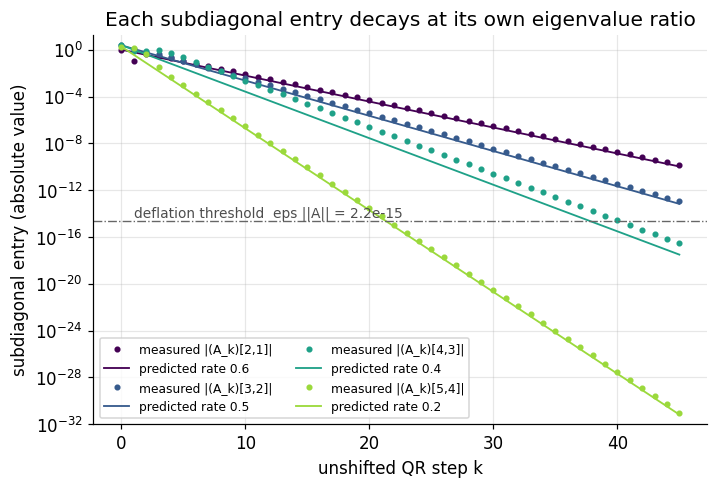

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ks = np.arange(K + 1)
colors = plt.cm.viridis(np.linspace(0.0, 0.85, 4))
for i in range(4):
    ax.semilogy(ks, sub[:, i], "o", ms=3.0, color=colors[i],
                label=f"measured |(A_k)[{i+2},{i+1}]|")
    ax.semilogy(ks, sub[0, i] * pred[i] ** ks, lw=1.2, color=colors[i],
                label=f"predicted rate {pred[i]:.1f}")
thresh = EPS * np.linalg.norm(Sqr, 2)
ax.axhline(thresh, color="0.4", lw=0.9, ls="-.")
ax.annotate(f"deflation threshold  eps ||A|| = {thresh:.1e}", (1.0, thresh * 2.5),
            fontsize=9, color="0.3")
ax.set_ylim(1e-32, 20.0)
ax.set_xlabel("unshifted QR step k")
ax.set_ylabel("subdiagonal entry (absolute value)")
ax.set_title("Each subdiagonal entry decays at its own eigenvalue ratio")
ax.legend(fontsize=8, ncol=2, loc="lower left")
plt.show()

Four point clouds, four straight lines, four different slopes. The slowest entry — the one with
ratio $0.6$ — is the one that decides when the whole matrix can be declared triangular, which is
why a practical code shifts: shifting changes those ratios.

The dash-dotted line is the deflation threshold $\varepsilon_{\mathrm{mach}}\lVert A \rVert$.
The fastest entry crosses it after about $21$ steps and the slowest has not crossed it after $45$;
a real implementation would have set the fast one to zero and split the problem into two smaller
ones long before the plot ends. Everything drawn below that line is mathematically correct and
numerically irrelevant.

### 7.3 Breaking the hypotheses of Theorem 4.4

Two hypotheses, two failures, run explicitly.

- $C = \left(\begin{smallmatrix}0 & 1 \\ 1 & 0\end{smallmatrix}\right)$ has
  $\lvert \lambda_1 \rvert = \lvert \lambda_2 \rvert = 1$. The unshifted algorithm is at a fixed
  point.
- $B = \left(\begin{smallmatrix}1 & 1 \\ 0 & 2\end{smallmatrix}\right)$ has distinct moduli but
  $X^{-1}$ has a zero leading principal minor, so it has no pivot-free LU factorization. The
  algorithm converges to the eigenvalues in the **wrong order**.

The cell also applies the Wilkinson shift of Definition 3.5 to the first case.

In [8]:
print("Failure 1: equal moduli, |lambda_1| = |lambda_2| = 1")
C = np.array([[0.0, 1.0], [1.0, 0.0]])
Ck = C.copy()
for k in range(1, 51):
    Q, R = qr_positive(Ck)
    Ck = R @ Q
    if k in (1, 5, 50):
        print(f"  after {k:2d} unshifted steps: A_k = {Ck.ravel()}   subdiagonal = {Ck[1,0]:.3f}")
assert abs(Ck[1, 0] - 1.0) < 1e-12
print("  eigenvalues of C:", np.linalg.eigvalsh(C), " -> never revealed")

Ck = C.copy()
for k in range(1, 4):
    mu = wilkinson_shift(Ck[0, 0], Ck[1, 0], Ck[1, 1])
    Q, R = qr_positive(Ck - mu * np.eye(2))
    Ck = R @ Q + mu * np.eye(2)
    print(f"  Wilkinson-shifted step {k}: mu = {mu:+.6f}   subdiagonal = {abs(Ck[1,0]):.3e}"
          f"   diagonal = {np.diag(Ck)}")
assert abs(Ck[1, 0]) < 1e-14
assert np.allclose(np.sort(np.diag(Ck)), [-1.0, 1.0])

print("\nFailure 2: X^-1 has no pivot-free LU factorization")
B = np.array([[1.0, 1.0], [0.0, 2.0]])
X = np.array([[1.0, 1.0], [1.0, 0.0]])              # columns: eigenvectors for 2, then for 1
Xinv = np.linalg.inv(X)
print("  B = X diag(2,1) X^-1 ?", np.allclose(X @ np.diag([2.0, 1.0]) @ Xinv, B))
print("  X^-1 =", Xinv.ravel(), "   leading principal minor (X^-1)_11 =", Xinv[0, 0])
Bk = B.copy()
for k in range(1, 31):
    Q, R = qr_positive(Bk)
    Bk = R @ Q
print("  after 30 unshifted steps: diag(A_k) =", np.diag(Bk),
      "  subdiagonal =", Bk[1, 0])
print("  the theorem would require diag -> (2, 1); it converged to (1, 2)")
assert abs(Xinv[0, 0]) < 1e-15
assert np.allclose(np.diag(Bk), [1.0, 2.0])

Failure 1: equal moduli, |lambda_1| = |lambda_2| = 1
  after  1 unshifted steps: A_k = [0. 1. 1. 0.]   subdiagonal = 1.000
  after  5 unshifted steps: A_k = [0. 1. 1. 0.]   subdiagonal = 1.000
  after 50 unshifted steps: A_k = [0. 1. 1. 0.]   subdiagonal = 1.000
  eigenvalues of C: [-1.  1.]  -> never revealed
  Wilkinson-shifted step 1: mu = -1.000000   subdiagonal = 0.000e+00   diagonal = [ 1. -1.]
  Wilkinson-shifted step 2: mu = -1.000000   subdiagonal = 0.000e+00   diagonal = [ 1. -1.]
  Wilkinson-shifted step 3: mu = -1.000000   subdiagonal = 0.000e+00   diagonal = [ 1. -1.]

Failure 2: X^-1 has no pivot-free LU factorization
  B = X diag(2,1) X^-1 ? True
  X^-1 = [ 0.  1.  1. -1.]    leading principal minor (X^-1)_11 = 0.0
  after 30 unshifted steps: diag(A_k) = [1. 2.]   subdiagonal = 0.0
  the theorem would require diag -> (2, 1); it converged to (1, 2)


The first matrix is a fixed point of the unshifted iteration: its QR factorization with positive
diagonal is $Q = C$, $R = I$, so $RQ = C$ again, and the subdiagonal entry is still exactly $1$
after fifty steps. The eigenvalues $\pm 1$ are never revealed. One Wilkinson-shifted step drives
the subdiagonal to zero and prints the diagonal $(1, -1)$ — this is precisely the situation
Definition 3.5 exists for, and it is why every production code shifts.

The second matrix is more insidious because it looks like a success: the subdiagonal is zero, so a
convergence test based on the subdiagonal passes immediately. But the diagonal is $(1, 2)$, the
eigenvalues in *increasing* modulus, contradicting the ordered conclusion of Theorem 4.4. Dropping
the LU hypothesis does not slow the algorithm down; it changes what the algorithm converges to.

### 7.4 Hand-rolled against the library

The cell below implements the standard dense symmetric eigensolver from scratch — Householder
reduction to tridiagonal form, then Wilkinson-shifted QR with deflation — and checks it against
`numpy.linalg.eigvalsh`. It also runs a hand-rolled Lanczos with full reorthogonalization on a
$200 \times 200$ matrix and compares its extreme Ritz values against the true extreme eigenvalues.

In [9]:
def house_tridiag(A):
    """Householder similarity reduction of a symmetric matrix to tridiagonal form."""
    Tw = A.copy()
    nn = Tw.shape[0]
    for k in range(nn - 2):
        x = Tw[k + 1:, k].copy()
        nx = np.linalg.norm(x)
        if nx == 0.0:
            continue
        sgn = 1.0 if x[0] >= 0.0 else -1.0
        v = x.copy()
        v[0] += sgn * nx
        nv = np.linalg.norm(v)
        if nv == 0.0:
            continue
        v /= nv                                   # unit reflector, P = I - 2 v v^T
        Bblk = Tw[k + 1:, k + 1:]
        pvec = Bblk @ v
        wvec = 2.0 * pvec - 2.0 * (v @ pvec) * v
        Tw[k + 1:, k + 1:] = Bblk - np.outer(v, wvec) - np.outer(wvec, v)
        Tw[k + 1:, k] = 0.0
        Tw[k, k + 1:] = 0.0
        Tw[k + 1, k] = Tw[k, k + 1] = -sgn * nx
    return Tw


def sym_eig_qr(A, tol=1e-14, max_steps=2000):
    """Symmetric eigenvalues by tridiagonalization plus Wilkinson-shifted QR with deflation."""
    Tw = house_tridiag(A)
    mm = Tw.shape[0]
    vals = []
    steps = 0
    while mm > 1 and steps < max_steps:
        if abs(Tw[mm - 1, mm - 2]) <= tol * (abs(Tw[mm - 1, mm - 1]) + abs(Tw[mm - 2, mm - 2])):
            vals.append(Tw[mm - 1, mm - 1])
            Tw = Tw[:mm - 1, :mm - 1].copy()
            mm -= 1
            continue
        steps += 1
        mu = wilkinson_shift(Tw[mm - 2, mm - 2], Tw[mm - 1, mm - 2], Tw[mm - 1, mm - 1])
        Q, R = qr_positive(Tw - mu * np.eye(mm))
        Tw = R @ Q + mu * np.eye(mm)
    vals.append(Tw[0, 0])
    return np.array(sorted(vals, reverse=True)), steps


Mh = rng.standard_normal((7, 7))
Ah = (Mh + Mh.T) / 2.0
Th = house_tridiag(Ah)
mine, nsteps = sym_eig_qr(Ah)
ref = np.linalg.eigvalsh(Ah)[::-1]
print("Householder tridiagonalization")
print(f"  largest entry outside the tridiagonal band: {np.abs(np.triu(Th, 2)).max():.2e}")
print(f"  spectrum preserved to {np.abs(np.linalg.eigvalsh(Th)-np.linalg.eigvalsh(Ah)).max()/EPS:.1f} eps")
print("\nWilkinson-shifted QR with deflation, 7 x 7 symmetric")
print("  hand-rolled :", mine)
print("  numpy eigvalsh:", ref)
print(f"  max |difference| = {np.abs(mine-ref).max():.3e} = {np.abs(mine-ref).max()/EPS:.1f} eps")
print(f"  shifted QR steps used: {nsteps}  ({nsteps/7:.2f} per eigenvalue)")
assert np.abs(np.triu(Th, 2)).max() < 1e-12
assert np.abs(mine - ref).max() < 1e-12


def lanczos(A, b, m, reorth=True):
    """m steps of Lanczos; returns alphas, betas and the basis Q (n x m+1)."""
    nn = A.shape[0]
    Qb = np.zeros((nn, m + 1))
    a = np.zeros(m)
    bt = np.zeros(m)
    Qb[:, 0] = b / np.linalg.norm(b)
    for j in range(m):
        w = A @ Qb[:, j]
        a[j] = Qb[:, j] @ w
        w = w - a[j] * Qb[:, j] - (bt[j - 1] * Qb[:, j - 1] if j > 0 else 0.0)
        if reorth:
            w = w - Qb[:, :j + 1] @ (Qb[:, :j + 1].T @ w)
            w = w - Qb[:, :j + 1] @ (Qb[:, :j + 1].T @ w)
        bt[j] = np.linalg.norm(w)
        Qb[:, j + 1] = w / bt[j] if bt[j] > 0.0 else 0.0
    return a, bt, Qb


nbig = 200
spec_big = np.concatenate([[12.0, 9.0, 7.0], np.linspace(0.5, 3.0, nbig - 3)])
Qbig, _ = np.linalg.qr(rng.standard_normal((nbig, nbig)))
Abig = Qbig @ np.diag(spec_big) @ Qbig.T
Abig = (Abig + Abig.T) / 2.0
mlan = 40
a_l, b_l, _ = lanczos(Abig, rng.standard_normal(nbig), mlan, reorth=True)
Tl = np.diag(a_l) + np.diag(b_l[:-1], 1) + np.diag(b_l[:-1], -1)
ritz, Sl = np.linalg.eigh(Tl)
res_l = b_l[mlan - 1] * np.abs(Sl[mlan - 1, :])
true_ext = np.linalg.eigvalsh(Abig)
order = np.argsort(-ritz)
print(f"\nLanczos, 200 x 200, m = {mlan} steps (40 matrix-vector products)")
print("  Ritz value        residual      nearest true eigenvalue    error")
for rank in (0, 1, 2, 3, 20, 39):
    i = order[rank]
    nearest = true_ext[int(np.argmin(np.abs(true_ext - ritz[i])))]
    print(f"  {ritz[i]:12.10f}    {res_l[i]:.2e}      {nearest:12.10f}         {abs(ritz[i]-nearest):.2e}")
print(f"  eigenvalue spacing inside the cluster [0.5, 3]: {2.5/(nbig-4):.6f}")
for rank in (0, 1, 2):
    i = order[rank]
    assert abs(ritz[i] - true_ext[nbig - 1 - rank]) < 1e-10
assert res_l[order[20]] > 1e-2

Householder tridiagonalization
  largest entry outside the tridiagonal band: 0.00e+00
  spectrum preserved to 8.0 eps

Wilkinson-shifted QR with deflation, 7 x 7 symmetric
  hand-rolled : [ 2.9054  1.7504  0.068  -0.1489 -2.247  -2.4761 -2.6033]
  numpy eigvalsh: [ 2.9054  1.7504  0.068  -0.1489 -2.247  -2.4761 -2.6033]
  max |difference| = 2.665e-15 = 12.0 eps
  shifted QR steps used: 13  (1.86 per eigenvalue)

Lanczos, 200 x 200, m = 40 steps (40 matrix-vector products)
  Ritz value        residual      nearest true eigenvalue    error
  12.0000000000    0.00e+00      12.0000000000         1.07e-14
  9.0000000000    2.24e-31      9.0000000000         3.55e-15
  7.0000000000    2.45e-30      7.0000000000         5.33e-15
  2.9999664355    2.75e-03      3.0000000000         3.36e-05
  1.8475331746    1.72e-01      1.8520408163         4.51e-03
  0.5000072501    9.87e-04      0.5000000000         7.25e-06
  eigenvalue spacing inside the cluster [0.5, 3]: 0.012755


The hand-rolled tridiagonalization leaves nothing outside the band and preserves the spectrum to a
few machine epsilons, and the shifted QR loop reproduces `eigvalsh` to within tens of epsilons
using about two shifted steps per eigenvalue — the textbook figure, and a direct consequence of
the cubic rate quoted in Theorem 4.9.

Lanczos with $40$ matrix-vector products on a $200 \times 200$ matrix returns the three separated
top eigenvalues $12$, $9$, $7$ to fourteen digits, with Ritz residuals at machine level. The fourth
Ritz value already carries a residual of $2.8 \times 10^{-3}$, and an interior one carries
$1.7 \times 10^{-1}$ — it sits $4.5 \times 10^{-3}$ from the nearest true eigenvalue, a third of
the local spacing $0.0128$, so it is not an eigenvalue estimate at all.

That asymmetry is the defining behaviour of Krylov eigensolvers: they resolve *separated* extremes
and ignore clusters. Asking one for a middle eigenvalue means shifting and inverting first, which
turns the interior eigenvalue into an extreme one of $(A - \mu I)^{-1}$ — Theorem 4.1 again.

### 7.5 Loss of orthogonality, and Paige's bound

Theorem 4.9 says that in floating point the Lanczos basis loses orthogonality in the direction of
a Ritz vector precisely as that Ritz pair converges, with
$\lvert q_{m+1}^{\top}y_i \rvert$ of order $u \lVert A \rVert_2$ divided by the residual
$\beta_m \lvert s_{mi} \rvert$ of Theorem 4.8.

The cell runs $70$ Lanczos steps on a $120 \times 120$ matrix with three well-separated top
eigenvalues, once without reorthogonalization and once with full reorthogonalization, and prints
the orthogonality defect $\lVert Q_k^{\top}Q_k - I \rVert_2$ against the smallest Ritz residual at
that step.

In [10]:
nL = 120
spec_L = np.concatenate([[8.0, 6.5, 5.2], np.linspace(0.1, 3.0, nL - 3)])
QL, _ = np.linalg.qr(rng.standard_normal((nL, nL)))
AL = QL @ np.diag(spec_L) @ QL.T
AL = (AL + AL.T) / 2.0
normA = np.linalg.norm(AL, 2)
bL = rng.standard_normal(nL)

mL = 70


def lanczos_trace(A, b, m, reorth):
    """Lanczos, recording orthogonality defect and smallest Ritz residual at each step."""
    nn = A.shape[0]
    Qb = np.zeros((nn, m + 1))
    a = np.zeros(m)
    bt = np.zeros(m)
    defect = np.zeros(m)
    resid = np.zeros(m)
    Qb[:, 0] = b / np.linalg.norm(b)
    for j in range(m):
        w = A @ Qb[:, j]
        a[j] = Qb[:, j] @ w
        w = w - a[j] * Qb[:, j] - (bt[j - 1] * Qb[:, j - 1] if j > 0 else 0.0)
        if reorth:
            w = w - Qb[:, :j + 1] @ (Qb[:, :j + 1].T @ w)
            w = w - Qb[:, :j + 1] @ (Qb[:, :j + 1].T @ w)
        bt[j] = np.linalg.norm(w)
        Qb[:, j + 1] = w / bt[j] if bt[j] > 0.0 else 0.0
        Tj = np.diag(a[:j + 1]) + np.diag(bt[:j], 1) + np.diag(bt[:j], -1)
        _, Sj = np.linalg.eigh(Tj)
        defect[j] = np.linalg.norm(Qb[:, :j + 1].T @ Qb[:, :j + 1] - np.eye(j + 1), 2)
        resid[j] = bt[j] * np.abs(Sj[j, :]).min()
    return defect, resid, a, bt


defect_no, resid_no, a_no, b_no = lanczos_trace(AL, bL, mL, reorth=False)
defect_re, resid_re, _, _ = lanczos_trace(AL, bL, mL, reorth=True)

print("step   ||Q^T Q - I||  no reorth   with reorth   smallest Ritz residual   Paige u||A||/res")
for k in (4, 9, 14, 19, 24, 39, 69):
    paige = (EPS / 2) * normA / max(resid_no[k], 1e-300)
    print(f"{k+1:4d}         {defect_no[k]:.3e}     {defect_re[k]:.3e}         "
          f"{resid_no[k]:.3e}            {min(paige, 1.0):.3e}")

Tno = np.diag(a_no) + np.diag(b_no[:-1], 1) + np.diag(b_no[:-1], -1)
ritz_no = np.linalg.eigvalsh(Tno)
ghosts = int(np.sum(np.abs(ritz_no - 8.0) < 1e-8))
print(f"\nwithout reorthogonalization, copies of the eigenvalue 8.0 among the {mL} Ritz values: {ghosts}")
print("top six Ritz values without reorthogonalization:", np.sort(ritz_no)[::-1][:6])
assert defect_re.max() < 1e-12
assert defect_no[-1] > 0.1
assert ghosts >= 2

step   ||Q^T Q - I||  no reorth   with reorth   smallest Ritz residual   Paige u||A||/res
   5         9.387e-16     2.385e-16         3.959e-01            2.243e-15
  10         6.034e-14     3.599e-16         1.672e-04            5.313e-12
  15         2.034e-09     4.794e-16         3.256e-09            2.728e-07
  20         1.134e-04     4.928e-16         5.772e-14            1.539e-02
  25         9.878e-01     5.034e-16         1.904e-16            1.000e+00
  40         1.000e+00     6.979e-16         1.261e-22            1.000e+00
  70         3.000e+00     7.307e-16         0.000e+00            1.000e+00

without reorthogonalization, copies of the eigenvalue 8.0 among the 70 Ritz values: 4
top six Ritz values without reorthogonalization: [8.  8.  8.  8.  6.5 6.5]


Up to step $10$ the two runs are nearly indistinguishable and orthogonality holds to $10^{-13}$.
Then the
smallest Ritz residual falls off a cliff — from $10^{-4}$ at step $10$ to $10^{-9}$ at step $15$ to
$10^{-14}$ at step $20$ — and the orthogonality defect of the unreorthogonalized run rises through
exactly the same decades, reaching $O(1)$ by step $25$. The two curves are mirror images, which is
the qualitative content of Paige's estimate: **convergence and loss of orthogonality are the same
event**.

The consequence is visible in the Ritz values: the converged eigenvalue $8.0$ appears four times
among the $70$ Ritz values of the unreorthogonalized run. Those are the notorious **ghost**
eigenvalues — the algorithm rediscovers a direction it has already found because it has forgotten
that it found it. Full reorthogonalization holds the defect at $10^{-16}$ throughout and produces
no ghosts, at a cost of $O(m^{2}n)$ instead of $O(mn)$.

The figure below draws both orthogonality histories together with the smallest Ritz residual.

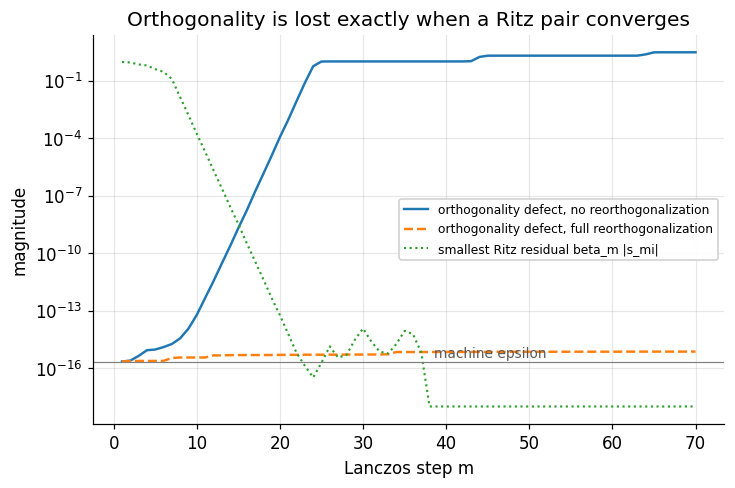

In [11]:
fig, ax = plt.subplots(figsize=(7.4, 4.6))
kk = np.arange(1, mL + 1)
ax.semilogy(kk, np.maximum(defect_no, 1e-18), lw=1.6,
            label="orthogonality defect, no reorthogonalization")
ax.semilogy(kk, np.maximum(defect_re, 1e-18), lw=1.6, ls="--",
            label="orthogonality defect, full reorthogonalization")
ax.semilogy(kk, np.maximum(resid_no, 1e-18), lw=1.4, ls=":",
            label="smallest Ritz residual beta_m |s_mi|")
ax.axhline(EPS, color="0.5", lw=0.8)
ax.annotate("machine epsilon", (mL * 0.55, EPS * 1.6), fontsize=9, color="0.35")
ax.set_xlabel("Lanczos step m")
ax.set_ylabel("magnitude")
ax.set_title("Orthogonality is lost exactly when a Ritz pair converges")
ax.legend(fontsize=8, loc="center right", framealpha=0.95)
plt.show()

The dotted residual curve falls; the solid defect curve rises; they cross near step $15$. Their
**product** is the invariant: $1.0 \times 10^{-17}$ at step $10$, $6.6\times10^{-18}$ at step
$15$, $6.5\times10^{-18}$ at step $20$ — pinned across five decades of movement in each factor.
That is Theorem 4.9 read off a plot; the unspecified constant in it appears here as the factor of
about $10^{-2}$ between that product and $u\lVert A \rVert = 8.9 \times 10^{-16}$.

The dashed line shows what reorthogonalization buys: a flat $10^{-16}$, immune to the whole drama.

## 8. Applications

Every setting below is an eigenvalue problem whose *size and structure* dictate which of the
algorithms above is the right one.

| Problem | Structure | Method | Why |
|---|---|---|---|
| PageRank | huge, sparse, column-stochastic, one eigenvalue wanted | power iteration | rate is $d$ by construction |
| Loss-surface curvature | $10^{8}$ parameters, matrix-free, extremes wanted | Lanczos | needs only $v \mapsto Hv$ |
| Normal modes | small, symmetric definite pencil, all modes wanted | tridiagonal shifted QR | $O(n^{3})$ is affordable |
| Ground-state energy | large, sparse, one extreme eigenvalue wanted | shifted inverse iteration or Lanczos | shift targets the ground state |
| Truncated SVD | rectangular, top $k$ singular values wanted | Golub-Kahan bidiagonalization | avoids forming $A^{\top}A$ |

### 8.1 PageRank

Let $P$ be **column-stochastic**, $P_{ij} = \mathbb{P}(\text{next page } i \mid \text{current page } j)$,
so $\mathbf{1}^{\top}P = \mathbf{1}^{\top}$, and let $d \in (0,1)$ be the damping factor. The
Google matrix is

$$
M = d P + \frac{1-d}{n}\mathbf{1}\mathbf{1}^{\top} .
$$

$M$ is again column-stochastic, so $\mathbf{1}^{\top}M = \mathbf{1}^{\top}$ and $1$ is an
eigenvalue. If $Pv = \lambda v$ with $\mathbf{1}^{\top}v = 0$ then
$Mv = dPv = d\lambda v$, so every eigenvalue of $M$ other than the Perron value satisfies
$\lvert \lambda \rvert \le d$.

By Theorem 4.1 with $\mu = 0$ reversed — that is, by power iteration — the error contracts by at
most $d$ per step, so

$$
k \;\ge\; \frac{\ln(1/\epsilon)}{\ln(1/d)}
$$

steps suffice for relative accuracy $\epsilon$, **independently of $n$**. At $d = 0.85$ and
$\epsilon = 10^{-6}$ that is $86$ iterations, whatever the size of the web.

The damping factor is not a modelling nicety. It is a deliberate manufacture of a spectral gap.

### 8.2 Curvature of a loss surface

For a network with $p$ parameters and empirical risk $J(\theta)$, the Hessian
$\nabla^{2}J(\theta) \in \mathbb{R}^{p \times p}$ cannot be stored: at $p = 10^{8}$ it needs
$4\times10^{4}$ terabytes.

It can still be *applied*. Pearlmutter's identity reads the Hessian-vector product as a
directional derivative of the gradient,

$$
\nabla^{2} J(\theta)\, v = \left. \frac{\partial}{\partial r} \nabla J(\theta + r v) \right\rvert_{r=0} ,
$$

which one forward-over-reverse automatic-differentiation pass evaluates exactly, in $O(p)$ memory
and about twice the cost of a gradient.

Theorem 4.7 needs nothing else. Feeding that product into $m \approx 100$ Lanczos steps returns the
largest and smallest curvatures — the quantities that set the stable learning rate $\eta \lt 2/L$
with $L = \lambda_1(\nabla^{2}J)$, and that reveal the near-null directions along which the minimum
is flat.

Theorem 4.9 is the warning label: without reorthogonalization those $100$ steps will report the top
eigenvalue several times over.

### 8.3 Physics: normal modes of a spring chain

Three equal masses $m$ on a line, connected to each other and to two walls by four identical
springs of stiffness $\kappa$, obey $m\ddot{x} = -\kappa K x$ with

$$
K = \begin{pmatrix} 2 & -1 & 0 \\ -1 & 2 & -1 \\ 0 & -1 & 2 \end{pmatrix} .
$$

Substituting $x = v\,e^{i\omega t}$ gives $Kv = (m\omega^{2}/\kappa) v$, so the squared natural
frequencies are $\omega_i^{2} = (\kappa/m)\lambda_i(K)$.

The matrix $K$ is the running matrix $T$ of Section 6 with the off-diagonal signs flipped, a change
of sign of alternate coordinates, so it has the **same** spectrum:

$$
\omega^{2} \in \left\lbrace (2-\sqrt2)\tfrac{\kappa}{m}, \ 2\tfrac{\kappa}{m}, \ (2+\sqrt2)\tfrac{\kappa}{m} \right\rbrace .
$$

The lowest mode has all three masses moving together, the middle mode has the centre mass at rest,
and the highest mode has neighbours in antiphase. Engineering interest is almost always in the
*lowest* frequency, which is the *smallest* eigenvalue — the case power iteration handles worst
and shifted inverse iteration handles best, with $\mu = 0$ giving the rate
$(2-\sqrt2)/2 \approx 0.29$ computed in Example 6.1.

### 8.4 Physics: the ground state of a one-dimensional Hamiltonian

The time-independent Schrödinger equation on $[0, 1]$ with Dirichlet walls and $\hbar = 2m = 1$,

$$
-\psi''(x) = E\,\psi(x), \qquad \psi(0) = \psi(1) = 0 ,
$$

discretizes on $N$ interior points with spacing $h = 1/(N+1)$ into the symmetric tridiagonal
eigenproblem $H\psi = E\psi$ with $H = h^{-2}\operatorname{tridiag}(-1, 2, -1)$.

Its eigenvalues are known exactly,

$$
E_k = \frac{4}{h^{2}}\sin^{2}\!\left( \frac{k \pi h}{2} \right) \longrightarrow k^{2}\pi^{2}
\quad \text{as } h \to 0 ,
$$

so the discretization can be checked against the physics: the ground state should approach
$\pi^{2} \approx 9.8696$.

The ground state is the eigenvalue of *smallest* modulus, so shifted inverse iteration with
$\mu = 0$ is the natural method: by Theorem 4.1 its rate is $E_1/E_2 \to 1/4$, four times faster
per step than power iteration would be on $H^{-1}$ without the structure. The next cell runs it.

### 8.5 Truncated SVD by Golub-Kahan bidiagonalization

For $A \in \mathbb{R}^{m \times n}$ the singular values of $A$ are the positive eigenvalues of the
symmetric augmented matrix $\left(\begin{smallmatrix} 0 & A \\ A^{\top} & 0\end{smallmatrix}\right)$.
Running Lanczos on that matrix from a starting vector supported on one block produces vectors that
alternate between the two blocks, and the recurrence splits into

$$
\alpha_i u_i = A v_i - \beta_{i-1} u_{i-1},
\qquad
\beta_i v_{i+1} = A^{\top}u_i - \alpha_i v_i ,
$$

with $\alpha_i, \beta_i \gt 0$ chosen to normalize. Collecting $k$ steps,

$$
A V_k = U_k B_k,
\qquad
A^{\top} U_k = V_{k+1} \widetilde{B}_k^{\top},
$$

where $B_k \in \mathbb{R}^{k \times k}$ is upper bidiagonal with diagonal $\alpha_1, \dots, \alpha_k$
and superdiagonal $\beta_1, \dots, \beta_{k-1}$, and

$$
\widetilde{B}_k = \begin{pmatrix} B_k & \beta_k e_k \end{pmatrix} \in \mathbb{R}^{k \times (k+1)}
$$

is $B_k$ with one extra **column**. That extra column is the whole difference between the two
identities, and it is the analogue of the $\beta_m q_{m+1}e_m^{\top}$ term in Theorem 4.7. It is
verified numerically in Problem L2.4 of [exercises.ipynb](exercises.ipynb).

The singular values of $B_k$ approximate the extreme singular values of $A$, and $B_k$ is
$k \times k$ bidiagonal, so its SVD is cheap. Nothing ever forms $A^{\top}A$, whose condition
number is the square of that of $A$.

The cell below runs the two applications that produce numbers: PageRank on a six-page graph, and
the ground state of the discretized Hamiltonian by shifted inverse iteration.

In [12]:
print("8.1  PageRank on a six-page graph")
links = {0: [1, 2], 1: [2], 2: [0, 3], 3: [4], 4: [3, 5], 5: [0, 3, 4]}
npages = 6
P = np.zeros((npages, npages))
for src, outs in links.items():
    for dst in outs:
        P[dst, src] = 1.0 / len(outs)
print("  column sums (column-stochastic):", P.sum(axis=0))
damp = 0.85
Mg = damp * P + (1.0 - damp) / npages * np.ones((npages, npages))
evM = np.linalg.eigvals(Mg)
evM = evM[np.argsort(-np.abs(evM))]
print("  eigenvalues of M (by modulus):", np.round(evM, 6))
print(f"  |lambda_2| = {abs(evM[1]):.6f}   bound d = {damp}")
assert abs(evM[1]) <= damp + 1e-12

wg, Vg = np.linalg.eig(Mg)
pi = np.real(Vg[:, int(np.argmin(np.abs(wg - 1.0)))])
pi = pi / pi.sum()
print("  stationary pi :", pi, "   ||M pi - pi|| =", np.linalg.norm(Mg @ pi - pi))
x0 = np.ones(npages) / npages
prev = None
for k in (1, 2, 5, 10, 20, 40):
    xk = np.linalg.matrix_power(Mg, k) @ x0
    err = np.linalg.norm(xk - pi)
    tail = "" if prev is None else f"   per-step ratio = {(err/prev[1])**(1/(k-prev[0])):.6f}"
    print(f"  k = {k:2d}   ||M^k x0 - pi|| = {err:.3e}{tail}")
    prev = (k, err)
kneed = int(np.ceil(6 * np.log(10) / (-np.log(damp))))
print(f"  iterations guaranteed for 1e-6 by the bound d = 0.85 : {kneed}")
assert np.linalg.norm(Mg @ pi - pi) < 1e-12

print("\n8.4  Ground state of -psi'' on [0,1] by shifted inverse iteration, mu = 0")
N = 200
h = 1.0 / (N + 1)
Ham = (np.diag(2.0 * np.ones(N)) + np.diag(-np.ones(N - 1), 1)
       + np.diag(-np.ones(N - 1), -1)) / h ** 2
E1_exact = 4.0 / h ** 2 * np.sin(np.pi * h / 2.0) ** 2
E2_exact = 4.0 / h ** 2 * np.sin(2.0 * np.pi * h / 2.0) ** 2
xs = rng.standard_normal(N)
xs /= np.linalg.norm(xs)
for _ in range(30):
    ys = np.linalg.solve(Ham, xs)
    xs = ys / np.linalg.norm(ys)
E1 = xs @ Ham @ xs
print(f"  discrete ground state, exact   : {E1_exact:.10f}")
print(f"  shifted inverse iteration gives: {E1:.10f}   error {abs(E1-E1_exact):.2e}")
print(f"  continuum limit pi^2           : {np.pi**2:.10f}   discretization error {abs(E1_exact-np.pi**2):.2e}")
print(f"  predicted convergence rate E1/E2 = {E1_exact/E2_exact:.6f}  (-> 1/4)")
assert abs(E1 - E1_exact) < 1e-9
assert abs(E1_exact - np.pi ** 2) < 1e-3

8.1  PageRank on a six-page graph
  column sums (column-stochastic): [1. 1. 1. 1. 1. 1.]
  eigenvalues of M (by modulus): [ 1.    +0.j    -0.5835+0.j    -0.386 -0.382j -0.386 +0.382j
  0.5055+0.j    -0.    +0.j   ]
  |lambda_2| = 0.583494   bound d = 0.85
  stationary pi : [0.1264 0.0787 0.1456 0.2408 0.2691 0.1394]    ||M pi - pi|| = 3.5245209804025386e-16
  k =  1   ||M^k x0 - pi|| = 1.212e-01
  k =  2   ||M^k x0 - pi|| = 5.506e-02   per-step ratio = 0.454362
  k =  5   ||M^k x0 - pi|| = 8.279e-03   per-step ratio = 0.531740
  k = 10   ||M^k x0 - pi|| = 2.992e-04   per-step ratio = 0.514744
  k = 20   ||M^k x0 - pi|| = 1.281e-06   per-step ratio = 0.579629
  k = 40   ||M^k x0 - pi|| = 2.087e-11   per-step ratio = 0.576243
  iterations guaranteed for 1e-6 by the bound d = 0.85 : 86

8.4  Ground state of -psi'' on [0,1] by shifted inverse iteration, mu = 0
  discrete ground state, exact   : 9.8694034814
  shifted inverse iteration gives: 9.8694034814   error 2.43e-13
  continuum limit 

The damped Google matrix has $\lvert \lambda_2 \rvert = 0.583$, comfortably under the guaranteed
bound $d = 0.85$, and the measured per-step contraction settles on that value rather than on the
bound — the bound is worst-case over all link structures, and a real graph does better. The
guarantee that $86$ iterations suffice at $d = 0.85$ holds regardless of $n$, which is what makes
the computation feasible at web scale.

For the Hamiltonian, thirty inverse-iteration steps reproduce the exact discrete ground state to
$10^{-13}$, and that discrete value differs from the continuum $\pi^{2}$ by $2 \times 10^{-4}$ —
the $O(h^{2})$ discretization error, not an iteration error. Separating those two errors is the
whole job: no amount of extra iteration improves the second one.

## 9. Key Takeaways

- **Every eigenvalue algorithm is iterative, by algebra and not by choice.** Abel-Ruffini closes
  the characteristic polynomial for $n \ge 5$, so the only question left is the rate.

- **The rate of a vector iteration is a ratio of spectral distances.** Power iteration contracts
  at $\lvert \lambda_2/\lambda_1 \rvert$, shifted inverse iteration at
  $\lvert \lambda_j - \mu \rvert / \min_{i \neq j}\lvert \lambda_i - \mu \rvert$ (Theorem 4.1),
  and refreshing the shift from the Rayleigh quotient makes the contraction itself quadratic, hence
  the iteration cubic (Theorem 4.2). Example 6.2 exhibits the exact recursion
  $\tan\delta_{k+1} = -\tan^{3}\delta_k$.

- **The QR algorithm is orthonormal subspace iteration on all $n$ nested coordinate subspaces at
  once**: $A^{k} = \underline{Q}_k\underline{R}_k$ and $A_k = \underline{Q}_k^{\top}A\underline{Q}_k$
  (Theorem 4.3). It gets the answer $A^{k}$ would give without ever forming $A^{k}$.

- **Unshifted QR converges, with hypotheses that select the answer** (Theorem 4.4). Diagonalizable,
  strictly decreasing eigenvalue moduli, no zero eigenvalue, and a pivot-free LU factorization of
  $X^{-1}$ give $\lvert (A_k)_{j+1,j} \rvert = O(\lvert \lambda_{j+1}/\lambda_j \rvert^{k})$ and
  $(A_k)_{jj} \to \lambda_j$ in decreasing modulus. Section 7.2 measures four separate rates
  $0.600000$, $0.500000$, $0.400000$, $0.200000$ against predictions of $0.6$, $0.5$, $0.4$, $0.2$.

- **Dropping a hypothesis changes the limit, not the speed.** With equal moduli the algorithm sits
  at a fixed point forever; without pivot-free LU it converges to the eigenvalues in the wrong
  order, with a subdiagonal of exactly zero to reassure the convergence test. Both are run in
  Section 7.3.

- **Structure is what makes it affordable.** Hessenberg form is preserved by a QR step and costs
  $O(n^{2})$ per step instead of $O(n^{3})$ (Theorem 4.5), a Hessenberg reduction is pinned down by
  its first column (Theorem 4.6), and the Wilkinson shift is the trailing-block eigenvalue nearest
  the corner, written so it does not cancel (Proposition 4.10). Together they give about two
  shifted steps per eigenvalue, measured in Section 7.4.

- **Krylov methods trade the whole spectrum for the separated ends of it.** Symmetry collapses
  Arnoldi to a three-term recurrence (Theorem 4.7), and the residual of every Ritz pair is known
  exactly as $\beta_m\lvert s_{mi} \rvert$ (Theorem 4.8) — a free, exact stopping test. Forty
  matrix-vector products pin the three separated top eigenvalues of a $200 \times 200$ matrix to
  fourteen digits, while an interior Ritz value carries a residual of $0.17$ and is not an
  eigenvalue estimate at all.

- **In floating point, convergence and loss of orthogonality are the same event** (Theorem 4.9).
  The orthogonality defect rises through the same decades that the smallest Ritz residual falls
  through, and an unreorthogonalized run reports the converged eigenvalue four times. Full
  reorthogonalization holds the defect at $10^{-16}$ for $O(m^{2}n)$ work.

## 10. References

**Textbooks.**

- Trefethen, L. N. and Bau, D. *Numerical Linear Algebra*, SIAM, 1997 — Lecture 25 (Hessenberg
  and tridiagonal reduction), Lecture 27 (Rayleigh quotient and inverse iteration, and the cubic
  rate), Lecture 28 (the QR algorithm without shifts, and its equivalence to simultaneous
  iteration), Lecture 29 (shifts and the Wilkinson shift), Lecture 33 (Arnoldi), Lecture 36
  (Lanczos).
- Golub, G. H. and Van Loan, C. F. *Matrix Computations*, 4th ed., Johns Hopkins, 2013 —
  section 7.3 (the unshifted QR iteration and its convergence), section 7.5 (the practical
  Hessenberg-QR algorithm and the Implicit Q theorem, Theorem 7.4.2), section 8.3 (symmetric QR,
  the Wilkinson shift and its cubic rate), section 8.4 (Jacobi methods), section 8.5
  (divide-and-conquer and the secular equation), section 10.1 (Lanczos and its loss of
  orthogonality).
- Parlett, B. N. *The Symmetric Eigenvalue Problem*, SIAM Classics, 1998 — Ch. 4 (Rayleigh
  quotient iteration), Ch. 8 section 8.10 (convergence of shifted QR), Ch. 13 section 13.4
  (Paige's theorem and selective reorthogonalization).
- Watkins, D. S. *The Matrix Eigenvalue Problem: GR and Krylov Subspace Methods*, SIAM, 2007 —
  Ch. 2 for the subspace-iteration reading of the QR algorithm used in Proof 5.4.
- Saad, Y. *Numerical Methods for Large Eigenvalue Problems*, 2nd ed., SIAM, 2011 — Ch. 6
  (Krylov subspace methods), Ch. 7 (filtering and restarting, including the implicitly restarted
  Arnoldi method).
- Wilkinson, J. H. *The Algebraic Eigenvalue Problem*, Oxford, 1965 — Ch. 8 section 39 for the
  global convergence of the shifted symmetric QR iteration.
- Horn, R. A. and Johnson, C. R. *Matrix Analysis*, 2nd ed., Cambridge, 2013 — section 2.4
  (Schur form), section 6.1 (Gershgorin), for the structural facts assumed here.

**Papers.**

- Francis, J. G. F. "The QR transformation, parts I and II", *The Computer Journal* **4**
  (1961-62), 265-271 and 332-345.
- Kublanovskaya, V. N. "On some algorithms for the solution of the complete eigenvalue problem",
  *USSR Computational Mathematics and Mathematical Physics* **1**(3) (1961), 637-657.
- Paige, C. C. "Error analysis of the Lanczos algorithm for tridiagonalizing a symmetric matrix",
  *IMA Journal of Applied Mathematics* **18**(3) (1976), 341-349 — Theorem 4 is the bound quoted
  in Theorem 4.9.
- Parlett, B. N. and Scott, D. S. "The Lanczos algorithm with selective orthogonalization",
  *Mathematics of Computation* **33**(145) (1979), 217-238.
- Cuppen, J. J. M. "A divide and conquer method for the symmetric tridiagonal eigenproblem",
  *Numerische Mathematik* **36** (1981), 177-195.
- Sorensen, D. C. "Implicit application of polynomial filters in a k-step Arnoldi method",
  *SIAM Journal on Matrix Analysis and Applications* **13**(1) (1992), 357-385 — the algorithm
  behind ARPACK and `scipy.sparse.linalg.eigsh`.
- Pearlmutter, B. A. "Fast exact multiplication by the Hessian", *Neural Computation* **6**(1)
  (1994), 147-160.
- Halko, N., Martinsson, P.-G. and Tropp, J. A. "Finding structure with randomness", *SIAM Review*
  **53**(2) (2011), 217-288.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions: [the notation register](../../docs/notation.md).
- Eigenvalues, the spectral theorem, Courant-Fischer, Gershgorin and the power-iteration rate:
  [Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb).
- Schur form, the SVD and Eckart-Young, used in Sections 8.5 and the augmented-matrix construction:
  [Module 07](../07_canonical_forms_and_svd/first_principles.ipynb).
- Krylov subspaces for *linear systems*, conditioning and the Chebyshev bound for conjugate
  gradients: [Module 08](../08_numerical_linear_algebra_iterative_solvers/first_principles.ipynb).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).